# ANALISE DE DADOS ENERGETICOS - PROJETO TFC
## Tratamento, Modelacao e Apoio a Decisao em Consumo e Producao Solar

**Notebook realizado por:** Mariana Polícia (a22308010)

**Dataset:** 2011-2012 Solar home electricity data v2.csv  
**Objetivo Geral:** Desenvolver um Smart Energy Advisor para analise, previsao e apoio a decisao energetica domestica  
**Categorias:** GC (Consumo Geral), GG (Producao Solar), CL (Cargas Controladas)

O objetivo do Smart Energy Advisor é criar uma ferramenta inteligente para auxiliar na gestão do consumo de energia em casa. 

O dataset utilizado é fornecido pela Ausgrid, distribuidora elétrica de Nova Gales do Sul, Austrália, que contém registos de consumo e produção solar de 300 habitações ao longo de um ano completo (julho 2011 a junho 2012), com granularidade de 30 minutos.

Optou-se por este dataset por ser muito variado ao longo do tempo e por conseguir diferenciar entre consumo geral (GC), produção fotovoltaica (GG) e cargas controladas (CL), o que possibilita simular o comportamento energético real das habitações e, a partir daí, criar modelos preditivos para fazer recomendações personalizadas.  

Vai ser analisado no contexto australiana e mais tarde convertido para um contexto português.

O propósito desta fase de EDA (Exploratory Data Analysis) é compreender a estrutura dos dados, identificar tendências temporais, verificar a integridade dos registros e definir métricas que serão essenciais para decisões técnicas durante a modelagem.

## 1. Imports e Configuração

In [178]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import xgboost as xgb
import sklearn.model_selection
import sklearn.metrics
from statsmodels.tsa.seasonal import STL
import joblib
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error, r2_score


## 2. Carregamento dos Dados

In [179]:
df = pd.read_csv("2011-2012 Solar home electricity data v2.csv", skiprows=1)
df_original = df.copy()

print(df.shape)
print(df.columns.tolist())
df.head()

(270304, 54)
['Customer', 'Generator Capacity', 'Postcode', 'Consumption Category', 'date', '0:30', '1:00', '1:30', '2:00', '2:30', '3:00', '3:30', '4:00', '4:30', '5:00', '5:30', '6:00', '6:30', '7:00', '7:30', '8:00', '8:30', '9:00', '9:30', '10:00', '10:30', '11:00', '11:30', '12:00', '12:30', '13:00', '13:30', '14:00', '14:30', '15:00', '15:30', '16:00', '16:30', '17:00', '17:30', '18:00', '18:30', '19:00', '19:30', '20:00', '20:30', '21:00', '21:30', '22:00', '22:30', '23:00', '23:30', '0:00', 'Row Quality']


,Customer,Generator Capacity,Postcode,Consumption Category,date,0:30,1:00,1:30,2:00,2:30,...,20:00,20:30,21:00,21:30,22:00,22:30,23:00,23:30,0:00,Row Quality
0,1,3.78,2076,CL,1/07/2011,1.250,1.250,1.250,0.625,0.219,...,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,1.063,NaN
1,1,3.78,2076,GC,1/07/2011,1.077,0.669,0.674,0.615,0.321,...,0.276,0.241,0.168,0.234,0.164,0.639,0.118,0.219,0.162,NaN
2,1,3.78,2076,GG,1/07/2011,0.000,0.000,0.000,0.000,0.000,...,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,NaN
3,1,3.78,2076,CL,2/07/2011,1.238,1.244,1.194,0.000,0.888,...,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,1.075,NaN
4,1,3.78,2076,GC,2/07/2011,0.476,0.130,0.044,0.094,0.032,...,0.234,0.306,0.183,0.240,0.170,0.506,0.224,0.088,0.084,NaN


In [180]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 270304 entries, 0 to 270303
Data columns (total 54 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   Customer              270304 non-null  int64  
 1   Generator Capacity    270304 non-null  float64
 2   Postcode              270304 non-null  int64  
 3   Consumption Category  270304 non-null  object 
 4   date                  270304 non-null  object 
 5   0:30                  270304 non-null  float64
 6   1:00                  270304 non-null  float64
 7   1:30                  270304 non-null  float64
 8   2:00                  270304 non-null  float64
 9   2:30                  270304 non-null  float64
 10  3:00                  270304 non-null  float64
 11  3:30                  270304 non-null  float64
 12  4:00                  270304 non-null  float64
 13  4:30                  270304 non-null  float64
 14  5:00                  270304 non-null  float64
 15  

Constantes globais usadas

In [181]:
# os meses começam em Julho porque foi quando se começou a colheita de dados
meses = ['Jul', 'Ago', 'Set', 'Out', 'Nov', 'Dez',
         'Jan', 'Fev', 'Mar', 'Abr', 'Mai', 'Jun']
dias_nomes = ['Seg', 'Ter', 'Qua', 'Qui', 'Sex', 'Sáb', 'Dom']
horas_labels = [f'{h:02d}:00' for h in range(24)]

## 3. Exploração Inicial dos Dados

Primeiramente foi explorada a estrutura geral do dataset, as suas dimensões, os tipos de dados presentes e as estatísticas descritivas básicas. Esta análise permite-nos ter uma primeira ideia sobre a qualidade e o conteúdo dos dados antes de avançarmos para o pré-processamento.

In [182]:
df.describe()

,Customer,Generator Capacity,Postcode,0:30,1:00,1:30,2:00,2:30,3:00,3:30,...,20:00,20:30,21:00,21:30,22:00,22:30,23:00,23:30,0:00,Row Quality
count,270304.000000,270304.000000,270304.000000,270304.000000,270304.000000,270304.000000,270304.000000,270304.000000,270304.000000,270304.000000,...,270304.000000,270304.000000,270304.000000,270304.000000,270304.000000,270304.000000,270304.000000,270304.000000,270304.000000,0.0
mean,149.868837,1.669159,2204.094183,0.193431,0.193709,0.184526,0.153864,0.129470,0.106671,0.095864,...,0.208908,0.210243,0.202958,0.191886,0.181743,0.180705,0.170264,0.172639,0.185077,NaN
std,87.363659,1.023161,89.020722,0.455022,0.464087,0.453922,0.388668,0.328876,0.263996,0.228170,...,0.390086,0.389401,0.377186,0.360217,0.347702,0.360050,0.360750,0.386192,0.428556,NaN
min,1.000000,1.000000,2008.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,NaN
25%,73.000000,1.020000,2100.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,NaN
50%,150.000000,1.500000,2251.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,NaN
75%,226.000000,2.000000,2265.000000,0.153000,0.148000,0.141000,0.131000,0.123000,0.115000,0.112000,...,0.299000,0.303000,0.294000,0.275000,0.251000,0.227000,0.192000,0.173000,0.162000,NaN
max,300.000000,9.990000,2330.000000,5.151000,5.716000,6.798000,5.866000,5.201000,5.072000,3.700000,...,7.805000,6.444000,6.207000,5.846000,7.033000,5.855000,6.238000,6.189000,5.798000,NaN


A tabela acima apresenta as estatísticas descritivas do dataset. 

Os valores de energia (kWh) variam entre 0 e aproximadamente 7,8 kWh por intervalo de 30 minutos, com médias relativamente baixas dado que a maioria dos intervalos noturnos apresentam consumos reduzidos ou nulos.

In [183]:
df.isnull().sum()

Customer                     0
Generator Capacity           0
Postcode                     0
Consumption Category         0
date                         0
0:30                         0
1:00                         0
1:30                         0
2:00                         0
2:30                         0
3:00                         0
3:30                         0
4:00                         0
4:30                         0
5:00                         0
5:30                         0
6:00                         0
6:30                         0
7:00                         0
7:30                         0
8:00                         0
8:30                         0
9:00                         0
9:30                         0
10:00                        0
10:30                        0
11:00                        0
11:30                        0
12:00                        0
12:30                        0
13:00                        0
13:30                        0
14:00   

A análise de valores em falta confirma que a única coluna com valores nulos é Row Quality, com 270 304 valores em falta, ou seja, está completamente vazia em todo o dataset. Todas as restantes 53 colunas estão completamente preenchidas, sem qualquer valor nulo.

Dado que a coluna Row Quality não acrescenta qualquer informação útil foi removida.

In [184]:
df = df.drop('Row Quality', axis=1)
df.head()

,Customer,Generator Capacity,Postcode,Consumption Category,date,0:30,1:00,1:30,2:00,2:30,...,19:30,20:00,20:30,21:00,21:30,22:00,22:30,23:00,23:30,0:00
0,1,3.78,2076,CL,1/07/2011,1.250,1.250,1.250,0.625,0.219,...,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,1.063
1,1,3.78,2076,GC,1/07/2011,1.077,0.669,0.674,0.615,0.321,...,0.381,0.276,0.241,0.168,0.234,0.164,0.639,0.118,0.219,0.162
2,1,3.78,2076,GG,1/07/2011,0.000,0.000,0.000,0.000,0.000,...,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000
3,1,3.78,2076,CL,2/07/2011,1.238,1.244,1.194,0.000,0.888,...,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,1.075
4,1,3.78,2076,GC,2/07/2011,0.476,0.130,0.044,0.094,0.032,...,0.262,0.234,0.306,0.183,0.240,0.170,0.506,0.224,0.088,0.084


In [185]:
print("Clientes:", df['Customer'].nunique())

print("Dias:",df['date'].nunique())

print("Número de Categorias:", df['Consumption Category'].nunique())

print("Categorias:", df['Consumption Category'].unique())

Clientes: 300
Dias: 366
Número de Categorias: 3
Categorias: ['CL' 'GC' 'GG']


O dataset contém dados de **300 clientes** ao longo de **366 dias** (julho de 2011 a junho de 2012), organizados em três categorias de consumo:

**CL** = Controlled Load (Consumo de Carga Controlada)

**GC** = General Consumption (Consumo Geral da Habitação)

**GG** = Gross Generation (Produção Solar Fotovoltaica)

## 4. Limpeza e Tratamento

Nesta fase, os dados foram preparados para a modelação, começando por identificar e ordenar as colunas temporais (intervalos de 30 minutos), converter o formato do dataset de largo para longo (wide to long), verificar os tipos de dados e criar um timestamp contínuo para cada registo.

Para garantir o rigor analítico, a transformação do dataset foi dividida em três etapas fundamentais:

1. No Formato Original, os dados brutos por cliente, onde o consumo e a produção solar aparecem distribuídos por categorias (GC, GG, CL) e intervalos temporais de 30 minutos.

In [186]:
# Colunas de tempo (intervalos de 30min)
time_cols = [c for c in df.columns if ':' in c]
time_cols = sorted(time_cols, key=lambda x: (int(x.split(':')[0]), int(x.split(':')[1])))



2. O Formato Longo onde se reorganiza os dados para uma estrutura de séries temporais, permitindo associar cada leitura a um timestamp contínuo.

In [187]:
id_cols = [
    'Customer', 
    'Generator Capacity', 
    'Postcode', 
    'Consumption Category', 
    'date']

# Reshape para formato longo
df_long = pd.melt(
    df,
    id_vars=id_cols,
    value_vars=time_cols,
    var_name='time',
    value_name='energy_kwh'
)


3. A Agregação por Timestamp, onde se consolidou as leituras de todos os clientes numa série temporal média. É importante destacar que o modelo de previsão atual incide sobre este padrão agregado (comportamento médio do sistema), facilitando a identificação de tendências macroscópicas de consumo e produção.

Para que um modelo de regressão consiga captar a sazonalidade do consumo elétrico, é necessário decompor a variável temporal em componentes cíclicas. Nesta etapa, foram extraídos o mês, o dia da semana e a hora, permitindo ao algoritmo distinguir, por exemplo, o perfil de consumo de um fim de semana comparado com um dia útil.

In [188]:
# Garante tipos de dados corretos
df_long['energy_kwh'] = pd.to_numeric(df_long['energy_kwh'], errors='coerce')
df_long['date'] = pd.to_datetime(df_long['date'], format='%d/%m/%Y', dayfirst=True)


In [189]:
# Criar o Timestamp Único
df_long['timestamp'] = pd.to_datetime(
    df_long['date'].dt.strftime('%Y-%m-%d') + ' ' + df_long['time'],
    format='%Y-%m-%d %H:%M',
    errors='coerce'
)

In [190]:
df_long['hour'] = df_long['timestamp'].dt.hour
df_long['weekday'] = df_long['timestamp'].dt.dayofweek
df_long['month'] = df_long['timestamp'].dt.month

Verificação da qualidade dos dados

In [191]:
datas_invalidas = df[df['date'].isna()]

print("Datas inválidas:", df['date'].isna().sum())


Datas inválidas: 0


In [192]:
df.duplicated()

print("Número de duplicados:", df.duplicated().sum())

Número de duplicados: 0


Não foram encontrados registos duplicados nem inválidos no dataset, o que é um bom indicador de qualidade dos dados. Cada linha representa de forma única a combinação entre cliente, data e categoria de consumo.

In [193]:
neg_total = (df[time_cols] < 0).sum().sum()
print("Total de valores negativos:", neg_total)

neg_por_categoria = (
    df.assign(neg_count=(df[time_cols] < 0).sum(axis=1))
      .groupby('Consumption Category')['neg_count']
      .sum()
)

print(neg_por_categoria)

Total de valores negativos: 0
Consumption Category
CL    0
GC    0
GG    0
Name: neg_count, dtype: int64


Também não foram encontrados valores negativos em nenhuma das categorias. Este resultado é relevante porque valores negativos em GC ou CL seriam fisicamente impossíveis, e em GG poderiam indicar erros de medição. Os dados estão, portanto, dentro dos limites esperados.

In [194]:
# Identificação de clientes com dados incompletos
clientes_incompletos = []
for cliente in df_original['Customer'].unique():
    cliente_data = df_original[df_original['Customer'] == cliente]
    if len(cliente_data) < 1098:  # 366 dias × 3 categorias
        clientes_incompletos.append(cliente)

print(f"Clientes com dados incompletos: {len(clientes_incompletos)}")

Clientes com dados incompletos: 162


A análise da qualidade dos dados foi aprofundada para além da simples contagem de registos, permitindo avaliar com maior detalhe a completude das séries. Verificou-se se cada combinação cliente-categoria apresentava o número esperado de dias ao longo do período em estudo e se, em cada dia observado, estavam presentes todas as 48 leituras de 30 minutos. De forma geral, os resultados indicam que a incompletude observada está sobretudo associada à ausência de dias inteiros em algumas séries, e não a falhas pontuais nas leituras intradiárias.

Foram identificados **162 clientes** com registos incompletos de 300, ou seja, com menos de 1098 linhas (366 dias × 3 categorias). Estes clientes podem ter entrado ou saído do programa de monitorização durante o período de recolha de dados.

In [195]:
print("Número de colunas de tempo:", len(time_cols))

Número de colunas de tempo: 48


#### Completude das Séries por Cliente e Categoria

A verificação granular da completude foi aprofundada em duas dimensões: o número de dias observados por combinação cliente-categoria e, dentro dos dias existentes, o número de leituras de 30 minutos presentes. Esta análise complementa a contagem global efetuada na fase de limpeza, permitindo identificar onde a incompletude é mais acentuada e qual a sua natureza.

Análise mais rigorosa dos dados incompletos:
 1) clientes/categorias com menos de 366 dias
 2) dias existentes com menos de 48 leituras de 30 minutos

In [196]:
# Análise mais rigorosa dos dados incompletos
# 1) clientes/categorias com menos de 366 dias

expected_days = 366

base_incompletos = df_long.dropna(subset=['Customer', 'Consumption Category', 'date', 'energy_kwh']).copy()
base_incompletos['day'] = base_incompletos['date'].dt.normalize()

resumo_incompletos = (
    base_incompletos
    .groupby(['Customer', 'Consumption Category'])
    .agg(
        dias_observados=('day', 'nunique'),
        leituras_observadas=('energy_kwh', 'count')
    )
    .reset_index()
)

resumo_incompletos['dias_em_falta'] = (expected_days - resumo_incompletos['dias_observados']).clip(lower=0)
clientes_categorias_incompletos = resumo_incompletos[resumo_incompletos['dias_observados'] < expected_days].copy()

print(f"Clientes/categorias com menos de {expected_days} dias: {len(clientes_categorias_incompletos)}")
print()
print(clientes_categorias_incompletos.sort_values(['dias_em_falta', 'Customer', 'Consumption Category'], ascending=[False, True, True]).head(10).to_string(index=False))


Clientes/categorias com menos de 366 dias: 1

 Customer Consumption Category  dias_observados  leituras_observadas  dias_em_falta
       27                   CL              196                 9408            170


A tabela apresenta as combinações cliente-categoria com maior número de dias em falta. Os casos mais extremos correspondem a séries com ausência prolongada de registos, possivelmente associados a clientes que aderiram ao programa de monitorização após o início do período de recolha ou que abandonaram antes do seu término.

In [197]:
# 2) dias existentes com menos de 48 leituras de 30 minutos


expected_readings_per_day = 48

leituras_por_dia = (
    base_incompletos
    .groupby(['Customer', 'Consumption Category', 'day'])
    .agg(leituras_observadas=('energy_kwh', 'count'))
    .reset_index()
)

leituras_por_dia['leituras_em_falta'] = (expected_readings_per_day - leituras_por_dia['leituras_observadas']).clip(lower=0)
dias_incompletos = leituras_por_dia[leituras_por_dia['leituras_observadas'] < expected_readings_per_day].copy()

print()
print(f"Dias com menos de {expected_readings_per_day} leituras de 30 minutos: {len(dias_incompletos)}")
print(f"Leituras em falta nesses dias: {dias_incompletos['leituras_em_falta'].sum()}")
print()
print(dias_incompletos.sort_values(['leituras_em_falta', 'Customer', 'Consumption Category', 'day'], ascending=[False, True, True, True]).head(10).to_string(index=False))

# Resumo por categoria, útil para discutir a qualidade dos dados no texto
resumo_categoria_incompletos = (
    resumo_incompletos.groupby('Consumption Category')
    .agg(
        clientes_categorias=('Customer', 'nunique'),
        media_dias_observados=('dias_observados', 'mean'),
        total_dias_em_falta=('dias_em_falta', 'sum')
    )
    .reset_index()
)

print()
print(resumo_categoria_incompletos.to_string(index=False))


Dias com menos de 48 leituras de 30 minutos: 0
Leituras em falta nesses dias: 0

Empty DataFrame
Columns: [Customer, Consumption Category, day, leituras_observadas, leituras_em_falta]
Index: []

Consumption Category  clientes_categorias  media_dias_observados  total_dias_em_falta
                  CL                  139             364.776978                  170
                  GC                  300             366.000000                    0
                  GG                  300             366.000000                    0


Dentro dos dias observados, não foram identificados dias com leituras intradiárias em falta, confirmando que a incompletude se manifesta exclusivamente como ausência de dias inteiros e não como falhas pontuais de 30 minutos. O resumo por categoria mostra que a distribuição da incompletude é relativamente uniforme entre GC, GG e CL, indicando que as ausências refletem a entrada/saída do cliente do sistema e não problemas específicos de um tipo de medição.

### 5. Análise Exploratória dos Dados

Nesta fase, analisamos as características específicas de cada categoria de consumo e produção de energia. O objetivo é validar se os dados seguem os comportamentos esperados (como a produção solar ocorrer apenas durante o dia) e identificar a variabilidade dos consumos, o que é crucial para a precisão das previsões futuras.

In [198]:
summary_categoria = []

for cat in ['GC', 'GG', 'CL']:
    temp = df[df['Consumption Category'] == cat]
    valores = temp[time_cols]

    summary_categoria.append({
        'categoria': cat,
        'media_kwh': valores.mean().mean(),
        'min_kwh': valores.min().min(),
        'max_kwh': valores.max().max(),
        'pct_zeros': (valores == 0).sum().sum() / valores.size * 100
    })

summary_categoria = pd.DataFrame(summary_categoria)
print(summary_categoria)

  categoria  media_kwh  min_kwh  max_kwh  pct_zeros
0        GC   0.326673      0.0    7.805   0.116044
1        GG   0.118578      0.0    4.419  54.288707
2        CL   0.105680      0.0    5.201  89.507156


A análise comparativa revela que o Consumo Geral (GC) apresenta a maior média e variabilidade, como esperado numa rede residencial. É interessante notar que as Cargas Controladas (CL) e a Produção Solar (GG) têm uma percentagem muito elevada de zeros (89.5% e 54.3%, respetivamente). No caso da produção solar, este padrão é coerente com a ausência de radiação solar durante a noite, reforçando a consistência física dos dados.

#### 5.1. Padrões de Consumo e Produção ao Longo do Dia

Para compreender a rotina energética dos clientes, calcula-se a média de consumo e produção para cada intervalo de 30 minutos. Estes perfis diários são fundamentais para a modelação, pois permitem ao algoritmo distinguir períodos de maior procura energética (horas de ponta) de intervalos de menor atividade.

In [199]:
df_gc = df[df['Consumption Category'] == 'GC']

df_gg = df[df['Consumption Category'] == 'GG']

df_cl = df[df['Consumption Category'] == 'CL']



Média de consumo e produção por categoria

<Axes: title={'center': 'Consumo Geral (GC) - Média por hora'}>

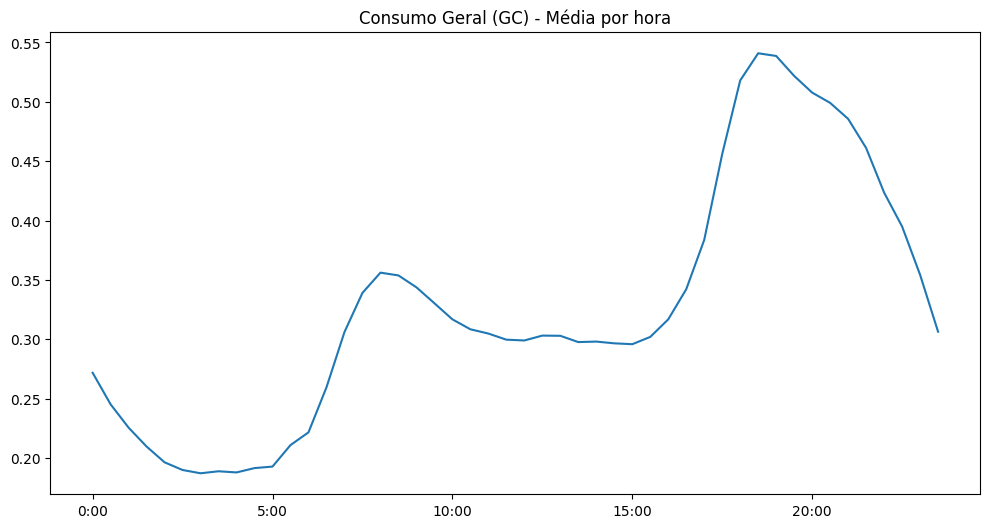

In [200]:
media_gc = df_gc[time_cols].mean()

media_gc.plot(figsize=(12,6), title="Consumo Geral (GC) - Média por hora")

<Axes: title={'center': 'Produção Solar (GG) - Média por hora'}>

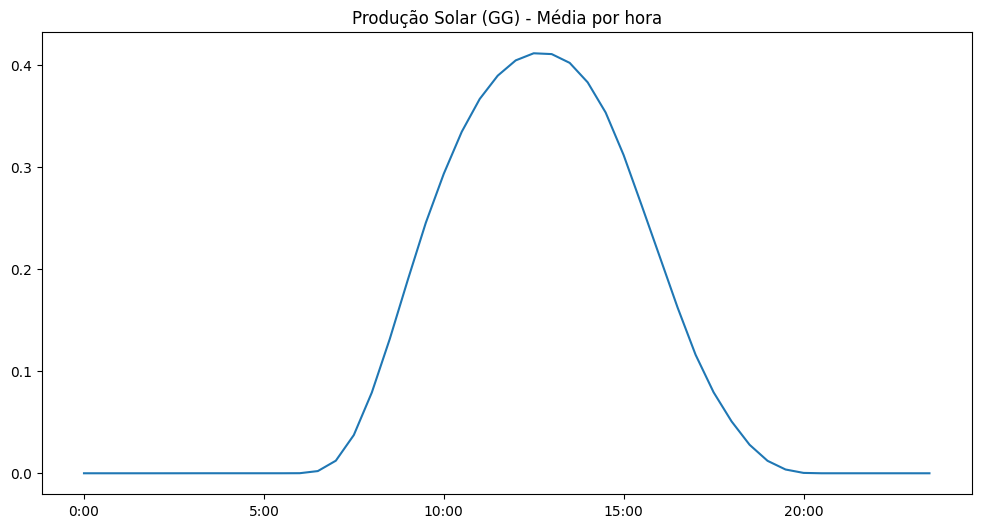

In [201]:
media_gg = df_gg[time_cols].mean()

media_gg.plot(figsize=(12,6), title="Produção Solar (GG) - Média por hora")

<Axes: title={'center': 'Cargas Controladas (CL) - Média por hora'}>

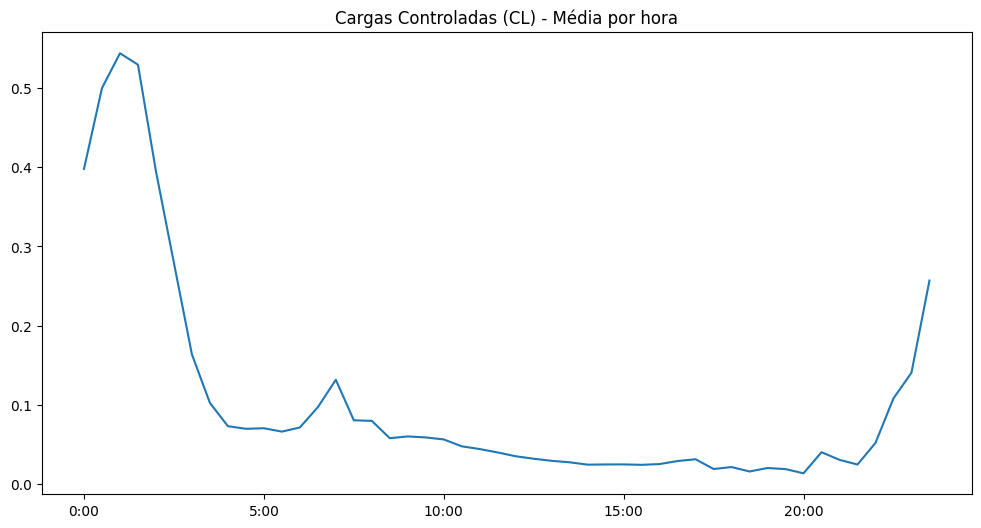

In [202]:
media_cl = df_cl[time_cols].mean()

media_cl.plot(figsize=(12,6), title="Cargas Controladas (CL) - Média por hora")

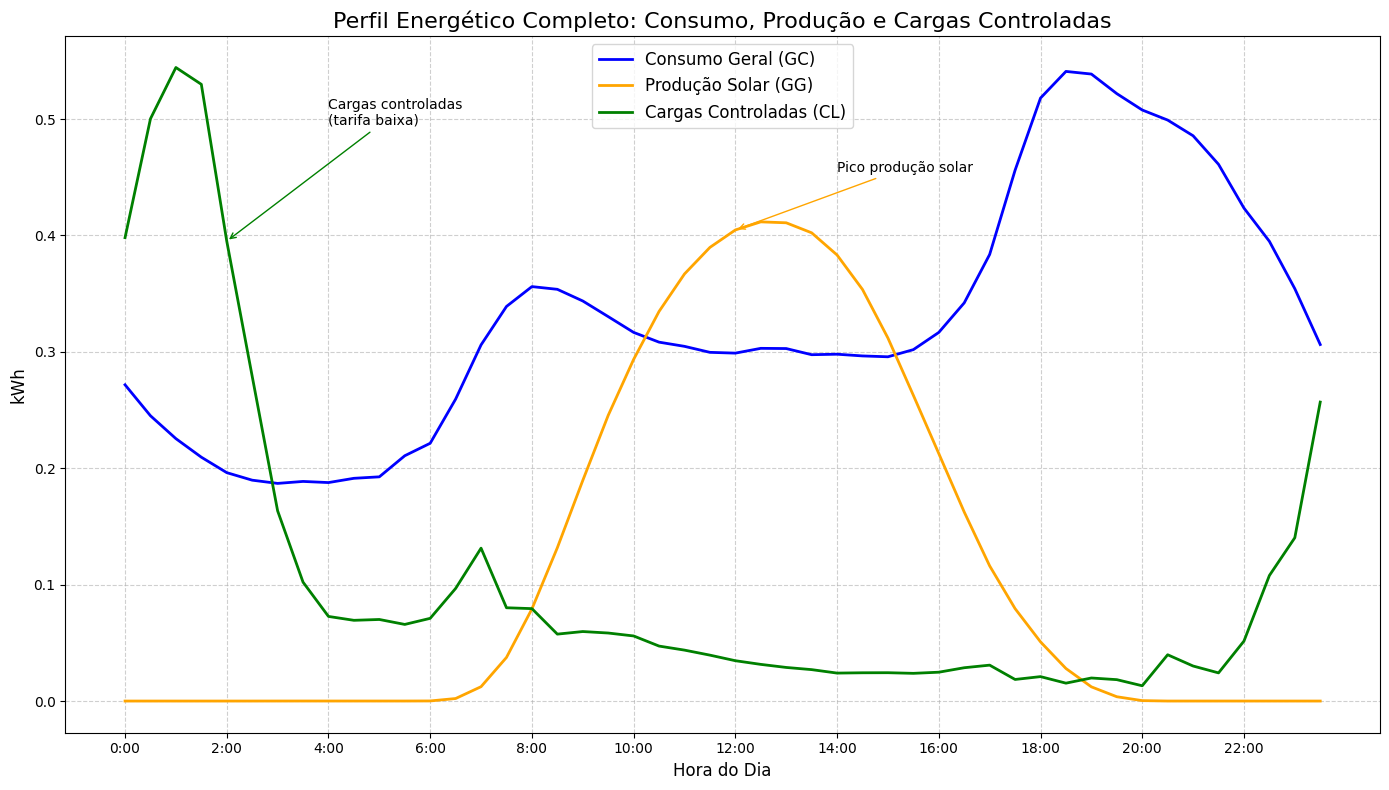

In [203]:
# Gráfico comparativo com todas as categorias
plt.figure(figsize=(14, 8))

plt.plot(range(48), media_gc, label='Consumo Geral (GC)', color='blue', linewidth=2)
plt.plot(range(48), media_gg, label='Produção Solar (GG)', color='orange', linewidth=2)
plt.plot(range(48), media_cl, label='Cargas Controladas (CL)', color='green', linewidth=2)

plt.title('Perfil Energético Completo: Consumo, Produção e Cargas Controladas', fontsize=16)
plt.xlabel('Hora do Dia', fontsize=12)
plt.ylabel('kWh', fontsize=12)
plt.xticks(range(0, 48, 4), [f'{i}:00' for i in range(0, 24, 2)])
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(fontsize=12)

# Anotações 
plt.annotate('Pico produção solar', xy=(24, media_gg.iloc[24]), xytext=(28, media_gg.iloc[24]+0.05),
            arrowprops=dict(arrowstyle='->', color='orange'))
plt.annotate('Cargas controladas\n(tarifa baixa)', xy=(4, media_cl.iloc[4]), xytext=(8, media_cl.iloc[4]+0.1),
            arrowprops=dict(arrowstyle='->', color='green'))

plt.tight_layout()
plt.show()

Os gráficos acima revelam padrões temporais distintos para cada categoria:

- **GC (Consumo Geral):** Apresenta dois picos de consumo, um de manhã (entre as 7h e as 9h) e outro ao final do dia (entre as 18h e as 21h), correspondendo aos períodos de maior atividade doméstica.
- **GG (Produção Solar):** Como esperado, a produção solar é nula durante a noite e atinge o seu máximo a meio do dia, entre as 11h e as 14h, refletindo a incidência solar.
- **CL (Cargas Controladas):** Apresenta um padrão mais concentrado nas horas de menor tarifa elétrica, tipicamente durante a madrugada, o que é consistente com o funcionamento de equipamentos como esquentadores elétricos em modo de tarifa controlada.

Estes padrões são fundamentais para a construção das *features* temporais utilizadas na modelação.

No conjunto, estes resultados confirmam a coerência dos dados com os padrões energéticos esperados e justificam a inclusão de variáveis temporais na fase de modelação.

## 6. Sazonalidade e Tendências de Consumo

Nesta secção, analisa-se como o consumo e a produção de energia se comportam em diferentes escalas temporais. O objetivo é identificar padrões cíclicos (sazonalidade) que se repetem mensalmente e semanalmente, permitindo ao modelo antecipar variações baseadas no calendário.

#### 6.1. Padrão Semanal do Consumo Geral (GC)

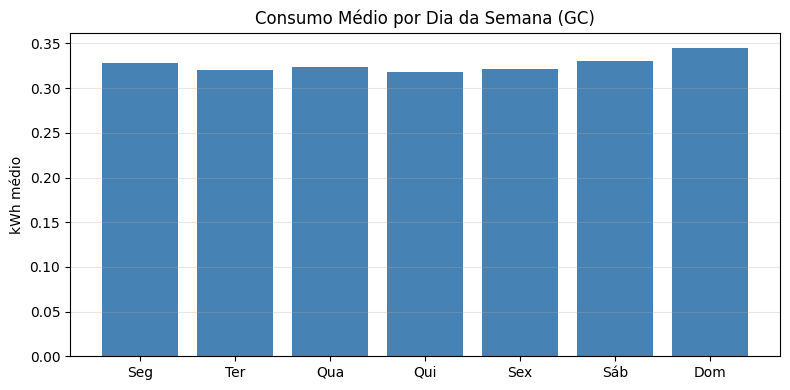

In [204]:

consumo_semana = (
    df_long[df_long['Consumption Category'] == 'GC']
    .groupby('weekday')['energy_kwh']
    .mean()
)

plt.figure(figsize=(8, 4))
plt.bar(range(7), consumo_semana.values, color='steelblue')
plt.xticks(range(7), dias_nomes)
plt.title('Consumo Médio por Dia da Semana (GC)')
plt.ylabel('kWh médio')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

O gráfico do consumo médio por dia da semana indica uma variação moderada entre dias úteis e fim de semana, sem ruturas abruptas no perfil agregado. Este resultado sugere que, embora exista efeito semanal, o consumo mantém uma base relativamente estável ao longo da semana. Para a modelação, esta evidência justifica a inclusão da variável dia da semana como preditor, dado o seu contributo para captar oscilações recorrentes de curta periodicidade.

#### 6.2. Perfil Médio Diário: Consumo versus Produção Solar

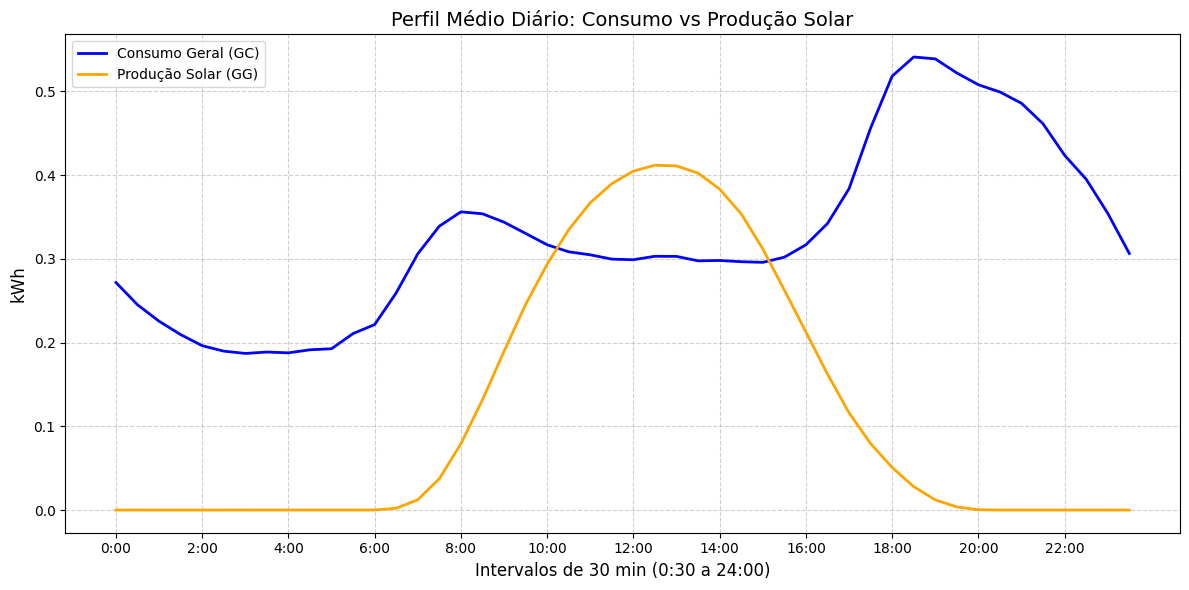

In [205]:
plt.figure(figsize=(12, 6))
plt.plot(range(48), media_gc, label='Consumo Geral (GC)', color='blue', linewidth=2)
plt.plot(range(48), media_gg, label='Produção Solar (GG)', color='orange', linewidth=2)

plt.title('Perfil Médio Diário: Consumo vs Produção Solar', fontsize=14)
plt.xlabel('Intervalos de 30 min (0:30 a 24:00)', fontsize=12)
plt.ylabel('kWh', fontsize=12)
plt.xticks(range(0, 48, 4), [f'{i}:00' for i in range(0, 24, 2)])
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.tight_layout()
plt.show()

A comparação entre consumo geral e produção solar evidencia complementaridades e desalinhamentos temporais relevantes. A produção fotovoltaica concentra-se no período diurno, com máximo próximo das horas centrais do dia, enquanto o consumo residencial tende a apresentar maior intensidade no início da manhã e, sobretudo, ao final da tarde e início da noite. Este desfasamento horário entre oferta local e procura reforça a importância de estratégias de gestão da procura e armazenamento para aumentar o autoconsumo.

#### 6.3. Comportamento das Cargas Controladas (CL)

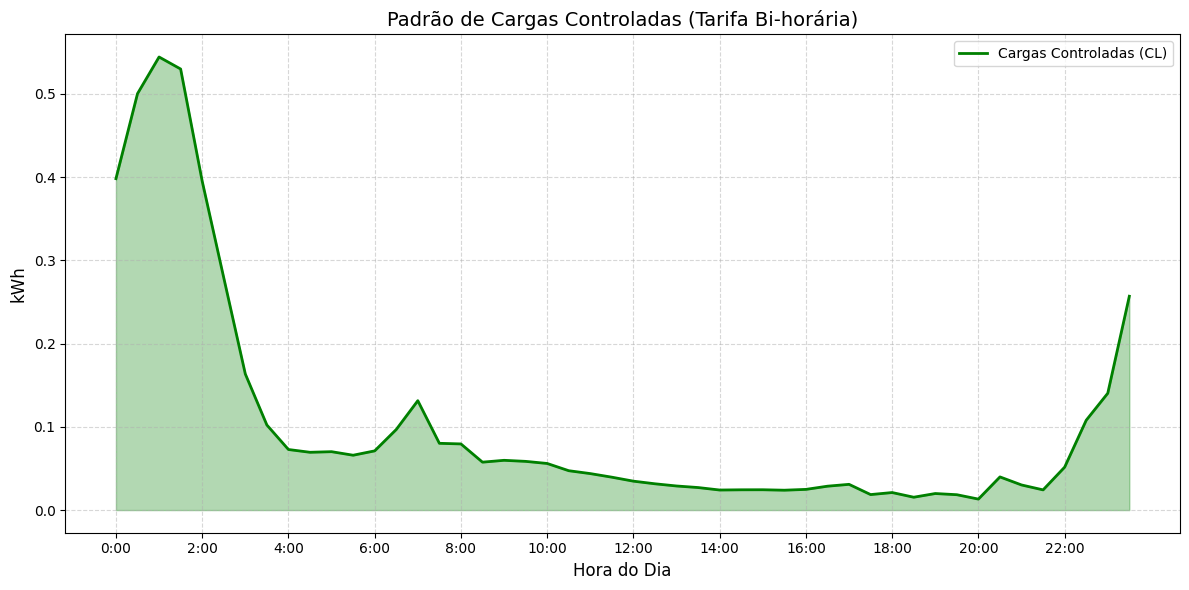

In [206]:
plt.figure(figsize=(12, 6))
plt.fill_between(range(48), media_cl, color='green', alpha=0.3)
plt.plot(range(48), media_cl, color='green', label='Cargas Controladas (CL)', linewidth=2)

plt.title('Padrão de Cargas Controladas (Tarifa Bi-horária)', fontsize=14)
plt.xlabel('Hora do Dia', fontsize=12)
plt.ylabel('kWh', fontsize=12)
plt.xticks(range(0, 48, 4), [f'{i}:00' for i in range(0, 24, 2)])
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()
plt.tight_layout()
plt.show()

O perfil das cargas controladas mostra concentração em períodos específicos, maioritariamente fora das horas de ponta, padrão compatível com tarifários bi-horários e acionamento programado de equipamentos. Esta estrutura temporal indica que parte do consumo é deslocável no tempo, o que constitui uma oportunidade para otimização energética. Do ponto de vista preditivo, trata-se de uma série com dinâmica própria, distinta do consumo geral e da produção sol

Em conjunto, os resultados confirmam a presença de sazonalidade semanal e diária no sistema energético analisado. A identificação destes padrões valida a engenharia de variáveis temporais e suporta a construção de modelos capazes de antecipar variações de consumo e produção com maior robustez.

### 7. Análises Avançadas

Nesta secção, aprofundam-se os indicadores de desempenho energético e a estrutura temporal das séries, com o objetivo de quantificar o autoconsumo, avaliar excedentes e défices, identificar padrões sazonais e caracterizar a variabilidade estatística das categorias GC, GG e CL.

#### 7.1 KPI 1: Taxa de Autoconsumo

O autoconsumo foi calculado como o mínimo entre produção solar e consumo em cada intervalo de 30 minutos. A taxa de autoconsumo resulta da razão entre o autoconsumo total e a produção total, permitindo medir a fração de energia fotovoltaica efetivamente utilizada localmente.

Autoconsumo = min(Produção, Consumo) em cada intervalo de 30 min

Taxa = Autoconsumo_total / Produção_total × 100

In [207]:


gc_vals = df_gc[time_cols].mean()   # Consumo médio por intervalo
gg_vals = df_gg[time_cols].mean()   # Produção média por intervalo

autoconsumo = np.minimum(gc_vals.values, gg_vals.values)

taxa_autoconsumo = autoconsumo.sum() / gg_vals.sum() * 100

print(f"Taxa de Autoconsumo: {taxa_autoconsumo:.1f}%")
print(f"Autoconsumo médio diário: {autoconsumo.sum():.2f} kWh")
print(f"Produção média diária: {gg_vals.sum():.2f} kWh")
print(f"Consumo médio diário (GC): {gc_vals.sum():.2f} kWh")

Taxa de Autoconsumo: 86.6%
Autoconsumo médio diário: 4.93 kWh
Produção média diária: 5.69 kWh
Consumo médio diário (GC): 15.68 kWh


Os resultados indicam o grau de aproveitamento local da energia produzida. Quanto maior a taxa de autoconsumo, menor a dependência de injeção de excedentes na rede e maior a eficiência energética do sistema. Este indicador é particularmente relevante para avaliar o potencial de medidas como armazenamento ou deslocação de cargas para períodos solares.

#### 7.2 KPI 2: Excedente Solar e Défice Energético

Excedente solar médio diário: 0.76 kWh (injetado na rede)
Défice energético médio diário: 10.75 kWh (importado da rede)
Rácio excedente/produção: 13.4%


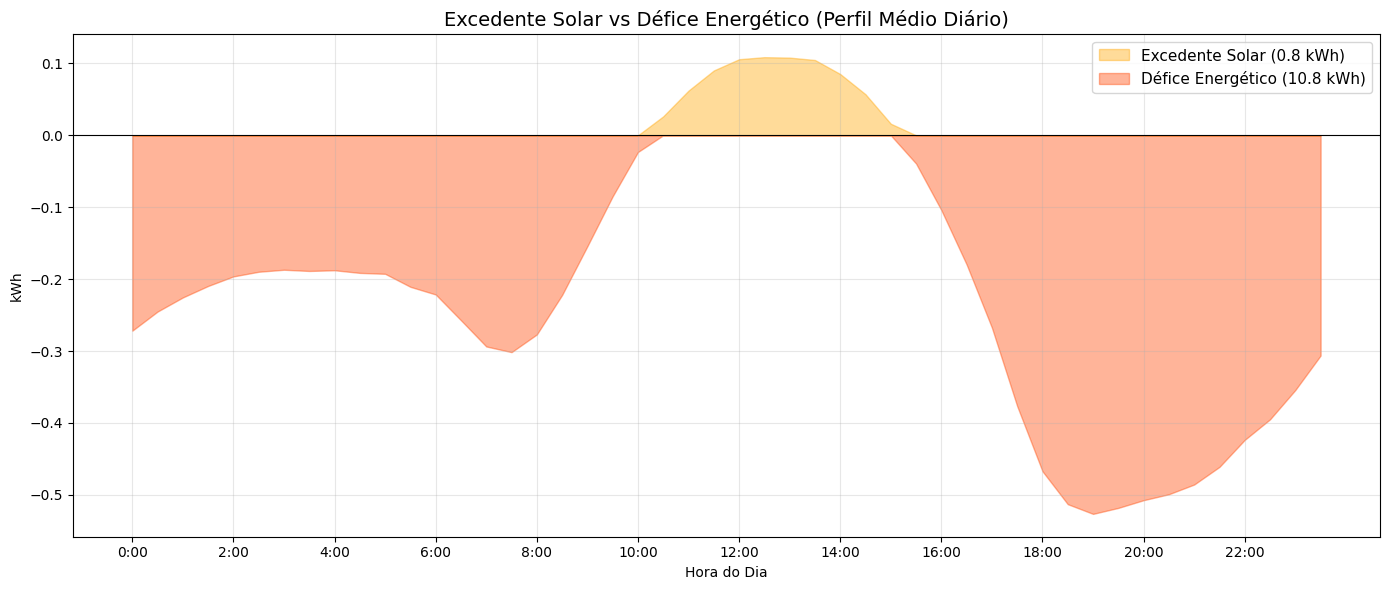

In [208]:
excedente = np.maximum(gg_vals.values - gc_vals.values, 0)
defice = np.maximum(gc_vals.values - gg_vals.values, 0)

excedente_total = excedente.sum()
defice_total = defice.sum()

print(f"Excedente solar médio diário: {excedente_total:.2f} kWh (injetado na rede)")
print(f"Défice energético médio diário: {defice_total:.2f} kWh (importado da rede)")
print(f"Rácio excedente/produção: {excedente_total / gg_vals.sum() * 100:.1f}%")

# Gráfico de área: Excedente vs Défice
fig, ax = plt.subplots(figsize=(14, 6))
horas_labels = [f'{h}:{m:02d}' for h in range(24) for m in (0, 30)]

ax.fill_between(range(48), excedente, alpha=0.4, color='orange', label=f'Excedente Solar ({excedente_total:.1f} kWh)')
ax.fill_between(range(48), -defice, alpha=0.4, color='orangered', label=f'Défice Energético ({defice_total:.1f} kWh)')
ax.axhline(y=0, color='black', linewidth=0.8)
ax.set_title('Excedente Solar vs Défice Energético (Perfil Médio Diário)', fontsize=14)
ax.set_xlabel('Hora do Dia')
ax.set_ylabel('kWh')
ax.set_xticks(range(0, 48, 4))
ax.set_xticklabels([f'{i}:00' for i in range(0, 24, 2)])
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

O gráfico evidencia a alternância entre dois regimes operacionais ao longo do dia: períodos com excedente solar, em que a produção supera o consumo, e períodos com défice, em que há necessidade de importação da rede. Em geral, o excedente concentra-se nas horas centrais do dia, enquanto o défice se intensifica no início da manhã e, sobretudo, ao final do dia. Este padrão confirma o desfasamento temporal entre geração fotovoltaica e procura residencial.

Visualização Complementar: Gráfico de Áreas Empilhadas

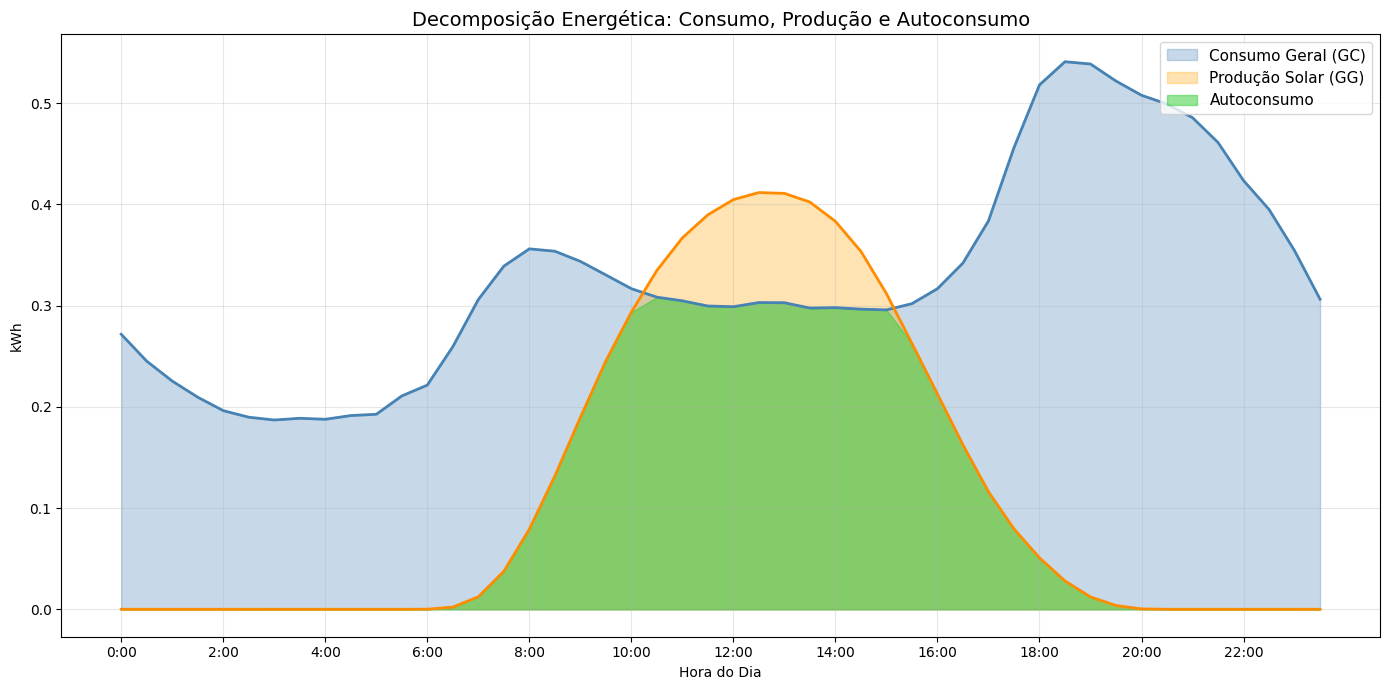

In [209]:
fig, ax = plt.subplots(figsize=(14, 7))

x = range(48)
ax.fill_between(x, gc_vals.values, alpha=0.3, color='steelblue', label='Consumo Geral (GC)')
ax.fill_between(x, gg_vals.values, alpha=0.3, color='orange', label='Produção Solar (GG)')
ax.plot(x, gc_vals.values, color='steelblue', linewidth=2)
ax.plot(x, gg_vals.values, color='darkorange', linewidth=2)

# Sombrear área de autoconsumo
ax.fill_between(x, autoconsumo, alpha=0.5, color='limegreen', label='Autoconsumo')

ax.set_title('Decomposição Energética: Consumo, Produção e Autoconsumo', fontsize=14)
ax.set_xlabel('Hora do Dia')
ax.set_ylabel('kWh')
ax.set_xticks(range(0, 48, 4))
ax.set_xticklabels([f'{i}:00' for i in range(0, 24, 2)])
ax.legend(fontsize=11, loc='upper right')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

A decomposição conjunta de consumo, produção e autoconsumo permite visualizar, de forma integrada, a parcela da produção solar efetivamente aproveitada. A área de autoconsumo representa a interseção entre as curvas de consumo e produção, sendo um indicador visual da eficiência de acoplamento entre oferta local e procura. Diferenças persistentes entre as curvas sugerem oportunidade para estratégias de gestão da procura e armazenamento.


#### 7.3 Heatmaps Temporais

Heatmap: Consumo Médio por Horas X Mês

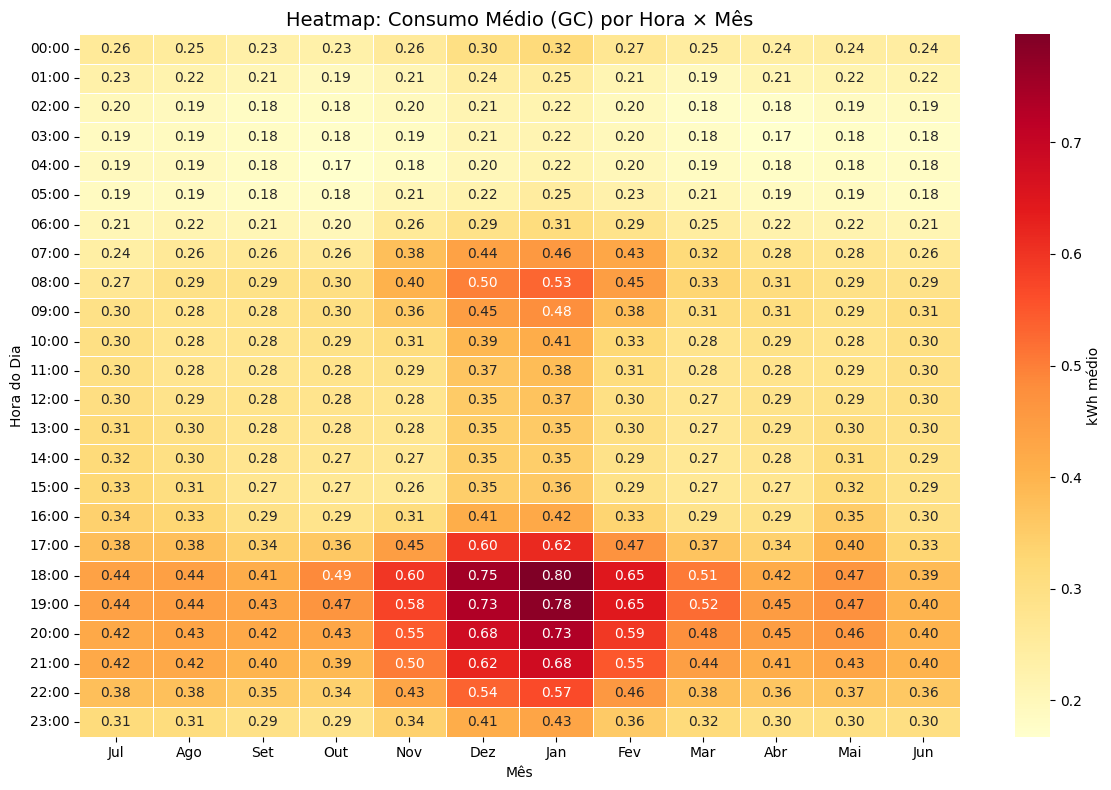

In [210]:
gc_long = df_long[df_long['Consumption Category'] == 'GC'].copy()

# A coluna 'hour' criada a partir de 'date' pode ficar toda a 0.
# Para o heatmap, usamos a hora real do timestamp.
gc_long = gc_long.dropna(subset=['timestamp', 'energy_kwh']).copy()
gc_long['hour_plot'] = gc_long['timestamp'].dt.hour

heatmap_data = gc_long.pivot_table(
    values='energy_kwh',
    index='hour_plot',
    columns='month',
    aggfunc='mean'
)

# Garantir que todas as horas (0-23) aparecem no eixo, mesmo sem dados em alguma hora
heatmap_data = heatmap_data.reindex(range(24))

heatmap_data.columns = [meses[m-1] for m in heatmap_data.columns]

plt.figure(figsize=(12, 8))
sns.heatmap(
    heatmap_data,
    cmap='YlOrRd',
    annot=True,
    fmt='.2f',
    linewidths=0.5,
    cbar_kws={'label': 'kWh médio'}
)
plt.title('Heatmap: Consumo Médio (GC) por Hora × Mês', fontsize=14)
plt.xlabel('Mês')
plt.ylabel('Hora do Dia')
plt.yticks(np.arange(24) + 0.5, [f'{h:02d}:00' for h in range(24)], rotation=0)
plt.tight_layout()
plt.show()

O heatmap mensal revela variacoes sazonais moderadas no consumo geral de energia.
Observa-se um ligeiro aumento de consumo durante os meses de verao na Australia (dezembro,
janeiro e fevereiro), atribuivel ao maior uso de climatizacao. Os periodos com
picos de consumo (manha e final do dia) mantem-se consistentes ao longo do ano,
sugerindo que os padroes circadianos dominam sobre os efeitos sazonais.
As tardes de verao apresentam consumos ligeiramente inferiores, possivelmente
devido a estilos de vida adaptados as temperaturas mais elevadas.

Heatmap: Produção Solar Média por Hora × Mês

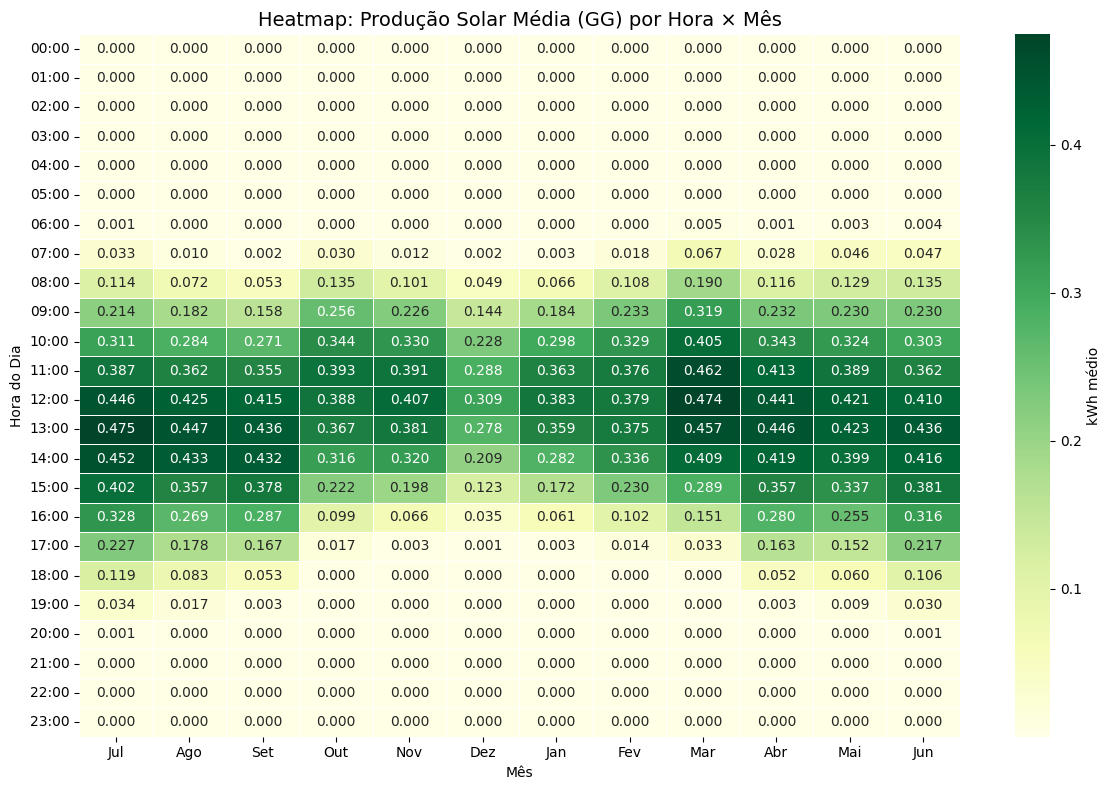

In [211]:
gg_long = df_long[df_long['Consumption Category'] == 'GG'].copy()

# Usar hora real do timestamp para evitar eixo de horas incorreto
gg_long = gg_long.dropna(subset=['timestamp', 'energy_kwh']).copy()
gg_long['hour_plot'] = gg_long['timestamp'].dt.hour

heatmap_solar = gg_long.pivot_table(
    values='energy_kwh',
    index='hour_plot',
    columns='month',
    aggfunc='mean'
)

# Garantir exibição de todas as horas (0-23)
heatmap_solar = heatmap_solar.reindex(range(24))

heatmap_solar.columns = [meses[m-1] for m in heatmap_solar.columns]

plt.figure(figsize=(12, 8))
sns.heatmap(
    heatmap_solar,
    cmap='YlGn',
    annot=True,
    fmt='.3f',
    linewidths=0.5,
    cbar_kws={'label': 'kWh médio'}
)
plt.title('Heatmap: Produção Solar Média (GG) por Hora × Mês', fontsize=14)
plt.xlabel('Mês')
plt.ylabel('Hora do Dia')
plt.yticks(np.arange(24) + 0.5, [f'{h:02d}:00' for h in range(24)], rotation=0)
plt.tight_layout()
plt.show()

A produção solar varia significativamente com as estações, refletindo as mudanças na duração do dia e incidência solar. Durante o verão (dezembro-fevereiro), o periodo produtivo é mais longo, concentrando-se entre as 7h e as 19h.

No inverno (junho-agosto), a produção solar torna-se mais curta, concentrando-se aproximadamente entre as 10h e as 15h.

Esta variabilidade sazonal e fundamental
para a modelação, exigindo que os modelos preditivos capturem não apenas ciclos diários, mas também efeitos sazonais complexos na geração de energia renovável.

Heatmap: Consumo Médio por Hora × Dia da Semana

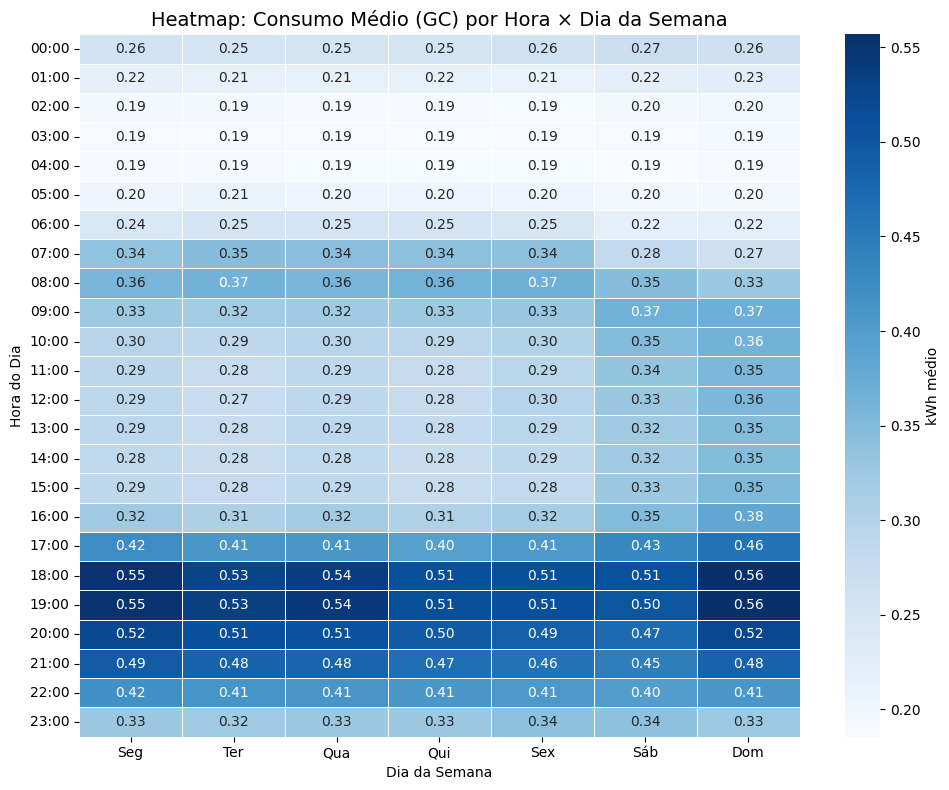

In [212]:
# Heatmap GC por hora e dia da semana com hora real do timestamp
gc_week = df_long[df_long['Consumption Category'] == 'GC'].copy()
gc_week = gc_week.dropna(subset=['timestamp', 'energy_kwh']).copy()
gc_week['hour_plot'] = gc_week['timestamp'].dt.hour

heatmap_weekday = gc_week.pivot_table(
    values='energy_kwh',
    index='hour_plot',
    columns='weekday',
    aggfunc='mean'
)

# Garantir exibição de todas as horas (0-23)
heatmap_weekday = heatmap_weekday.reindex(range(24))

heatmap_weekday = heatmap_weekday.reindex(columns=range(7))
heatmap_weekday.columns = dias_nomes

plt.figure(figsize=(10, 8))
sns.heatmap(
    heatmap_weekday,
    cmap='Blues',
    annot=True,
    fmt='.2f',
    linewidths=0.5,
    cbar_kws={'label': 'kWh médio'}
)
plt.title('Heatmap: Consumo Médio (GC) por Hora × Dia da Semana', fontsize=14)
plt.xlabel('Dia da Semana')
plt.ylabel('Hora do Dia')
plt.yticks(np.arange(24) + 0.5, [f'{h:02d}:00' for h in range(24)], rotation=0)
plt.tight_layout()
plt.show()

A distribuição por dia da semana mostra diferenças moderadas entre dias úteis e fim de semana, mantendo-se, contudo, a estrutura intradiária típica do consumo residencial. Assim, o efeito semanal existe, mas sem alterar de forma estrutural os horários de pico. Esta evidência sustenta o uso de variáveis de calendário no modelo preditivo.

#### 7.4 Outliers e Distribuição

Análise de Outliers (IQR)

In [213]:
# Verificar outliers
for cat_nome, cat_code in [('Consumo Geral', 'GC'), ('Produção Solar', 'GG'), ('Cargas Controladas', 'CL')]:
    cat_data = df_long[df_long['Consumption Category'] == cat_code]['energy_kwh'].dropna()

    Q1 = cat_data.quantile(0.25)
    Q3 = cat_data.quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    n_outliers = ((cat_data < lower) | (cat_data > upper)).sum()
    pct = n_outliers / len(cat_data) * 100

    print(f"   {cat_nome} ({cat_code}):")
    print(f"   Q1={Q1:.3f}  Q3={Q3:.3f}  IQR={IQR:.3f}")
    print(f"   Limites: [{lower:.3f}, {upper:.3f}]")
    print(f"   Outliers: {n_outliers:,} ({pct:.1f}%)")
    print()


   Consumo Geral (GC):
   Q1=0.110  Q3=0.381  IQR=0.271
   Limites: [-0.297, 0.788]
   Outliers: 481,468 (9.1%)

   Produção Solar (GG):
   Q1=0.000  Q3=0.150  IQR=0.150
   Limites: [-0.225, 0.375]
   Outliers: 568,259 (10.8%)

   Cargas Controladas (CL):
   Q1=0.000  Q3=0.000  IQR=0.000
   Limites: [0.000, 0.000]
   Outliers: 255,374 (10.5%)



A análise IQR quantifica a ocorrência de valores extremos em cada categoria e ajuda a distinguir eventos raros de comportamento operativo normal. Em séries energéticas, parte dos outliers pode refletir episódios reais de consumo ou produção elevada, não necessariamente erro de medição. Por isso, estes valores devem ser avaliados com critério antes de qualquer remoção.

Boxplots: Distribuição e Outliers

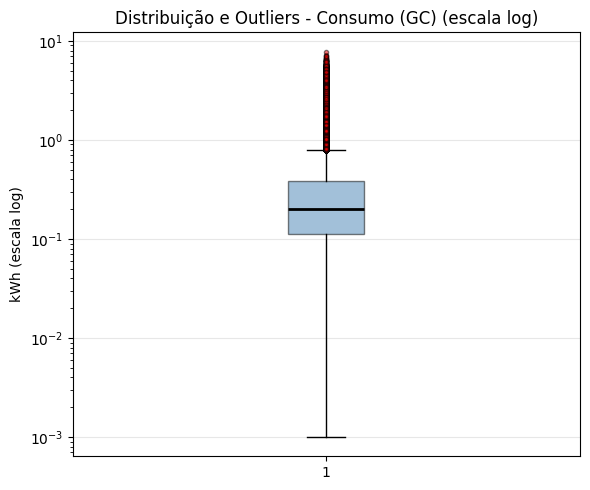

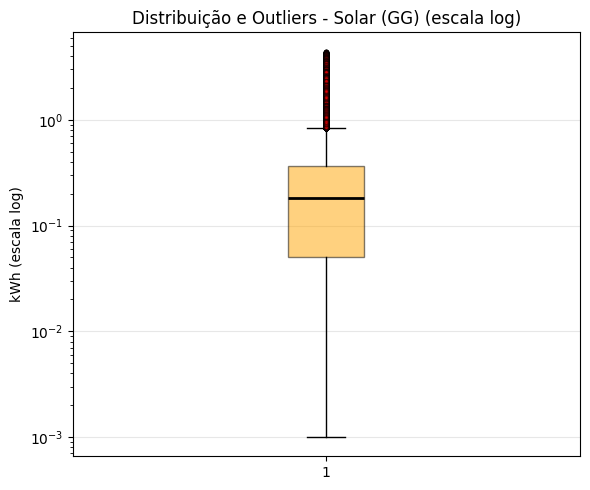

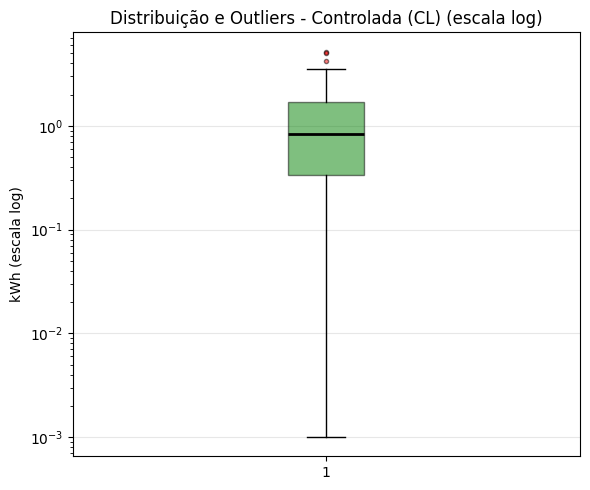

In [214]:
categorias = [
    ('Consumo (GC)', 'GC', 'steelblue'),
    ('Solar (GG)', 'GG', 'orange'),
    ('Controlada (CL)', 'CL', 'green'),
]

for cat_nome, cat_code, cor in categorias:
    data = df_long[df_long['Consumption Category'] == cat_code]['energy_kwh'].dropna()
    data_pos = data[data > 0]  # evita problemas com log(0)

    plt.figure(figsize=(6, 5))
    plt.boxplot(
        data_pos,
        vert=True,
        patch_artist=True,
        showfliers=True,
        boxprops=dict(facecolor=cor, alpha=0.5),
        medianprops=dict(color='black', linewidth=2),
        flierprops=dict(marker='o', markersize=3, alpha=0.5, markerfacecolor='red')
    )
    plt.yscale('log')
    plt.title(f'Distribuição e Outliers - {cat_nome} (escala log)')
    plt.ylabel('kWh (escala log)')
    plt.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    plt.show()

Os boxplots confirmam distribuições assimétricas e presença de caudas longas, especialmente relevantes em dados energéticos de alta granularidade temporal. A visualização em escala logarítmica melhora a leitura da dispersão e facilita a comparação entre categorias com amplitudes distintas. Para modelação, esta estrutura recomenda métodos robustos a assimetria e heterocedasticidade.

#### 7.5 Matriz de Correlação

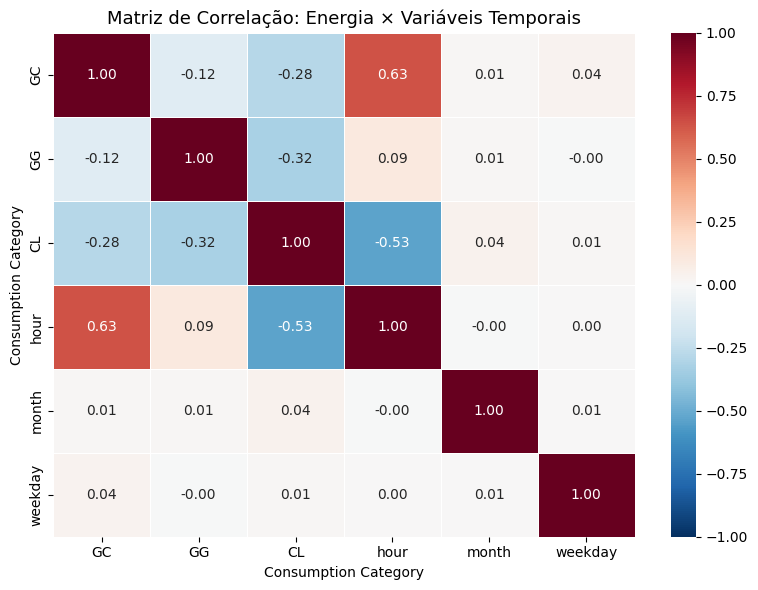

In [215]:
corr_data = df_long.pivot_table(
    values='energy_kwh',
    index=['date', 'hour'],
    columns='Consumption Category',
    aggfunc='mean'
).reset_index()

corr_data['month'] = corr_data['date'].dt.month
corr_data['weekday'] = corr_data['date'].dt.dayofweek

cols_corr = ['GC', 'GG', 'CL', 'hour', 'month', 'weekday']
# Filtrar apenas colunas que existam
cols_corr = [c for c in cols_corr if c in corr_data.columns]

plt.figure(figsize=(8, 6))
sns.heatmap(corr_data[cols_corr].corr(), annot=True, cmap='RdBu_r',
            center=0, fmt='.2f', linewidths=0.5, vmin=-1, vmax=1)
plt.title('Matriz de Correlação: Energia × Variáveis Temporais', fontsize=13)
plt.tight_layout()
plt.show()

A matriz de correlação entre variáveis energéticas e temporais revela relações 
importantes para modelação. Observa-se correlação positiva moderada entre hora do dia 
e consumo (GC), refletindo os picos conhecidos de manhã e final do dia. A produção 
solar (GG) apresenta correlação positiva com hora do dia, com máximo ao meio-dia. 
As cargas controladas (CL) mostram padrão de correlação negativa com hora, 
consistente com ativação durante horas de menor tarifa. Estas correlações 
justificam a inclusão de variáveis temporais (hora, mês, dia da semana) como 
preditores. As correlações moderadas (|r| < 0.6) indicam que nenhuma relação 
é dominante, sugerindo benefício de modelos não-lineares que capturem interações.

#### 7.6 Decomposição STL

A decomposição STL do consumo de energia revela três componentes distintos:

- **Tendência:** Apresenta uma estabilidade relativa ao longo do período, sem tendências 
de crescimento ou decréscimo significativos, sugerindo que os padrões de consumo 
residencial mantêm-se coerentes ao longo do ano.

- **Sazonalidade:** Concentra-se principalmente em variações semanais e diárias, 
refletindo ritmos de vida regulares. A componente sazonal é muito mais pronunciada 
que a tendência, confirmando que o consumo é primariamente governado por ciclos 
repetitivos.

- **Ruído:** O ruído residual é reduzido, indicando que a maior parte da variabilidade 
temporal é explicada pelos componentes estruturados, o que é favorável para modelação 
preditiva com algoritmos baseados em padrões.

##### Decomposição Sazonal - Consumo Geral (GC)

Nesta etapa, agrega-se o consumo geral (GC) por dia para construir uma série temporal diária regular. Em seguida, aplica-se a decomposição STL (período de 7 dias, modo robusto), permitindo separar tendência, sazonalidade semanal e componente residual para análise do comportamento do consumo.

In [216]:

# Série diária de consumo (GC) — média por dia
gc_diario = (
    df_long[df_long['Consumption Category'] == 'GC']
    .groupby('date')['energy_kwh']
    .mean()
    .sort_index()
)

# Remover NaN
gc_diario = gc_diario.dropna()

# STL com período sazonal de 7 dias (semanal)
stl = STL(gc_diario, period=7, robust=True)
resultado = stl.fit()



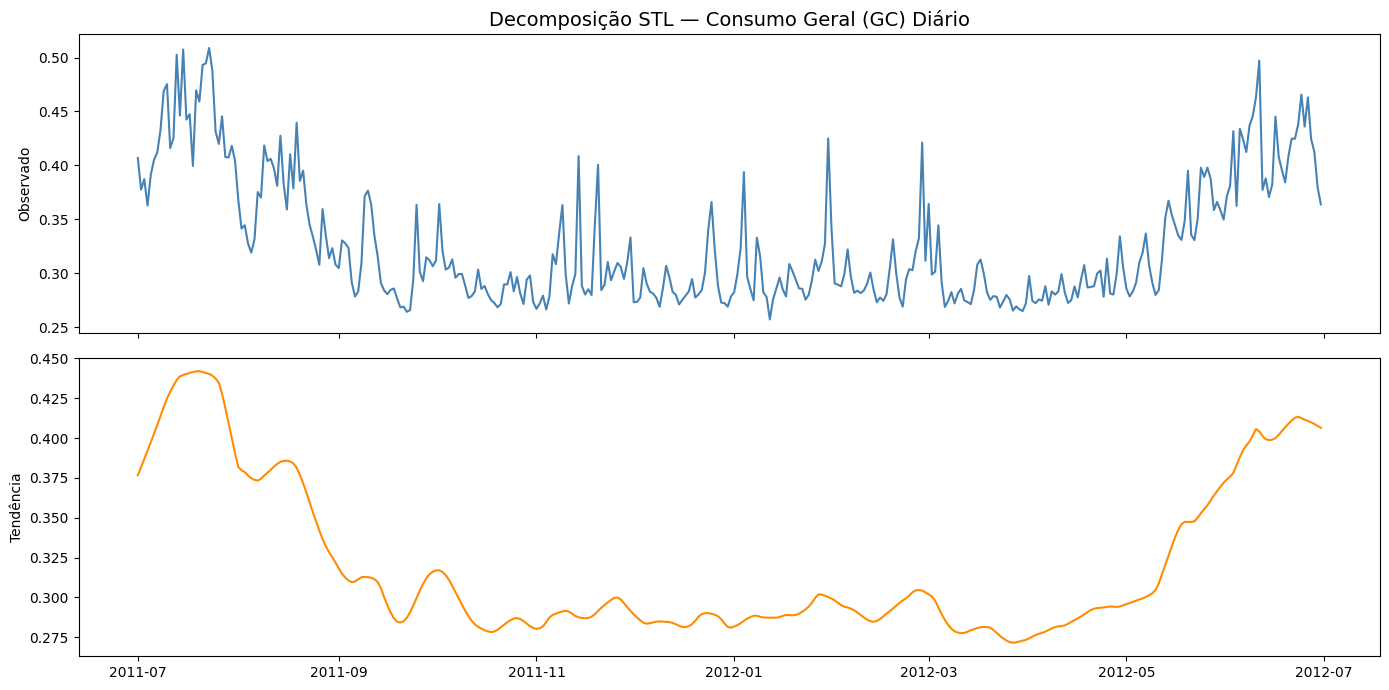

In [217]:
fig, axes = plt.subplots(2, 1, figsize=(14, 7), sharex=True)

axes[0].plot(gc_diario.index, resultado.observed, color='steelblue')
axes[0].set_ylabel('Observado')
axes[0].set_title('Decomposição STL — Consumo Geral (GC) Diário', fontsize=14)

axes[1].plot(gc_diario.index, resultado.trend, color='darkorange')
axes[1].set_ylabel('Tendência')


plt.tight_layout()
plt.show()



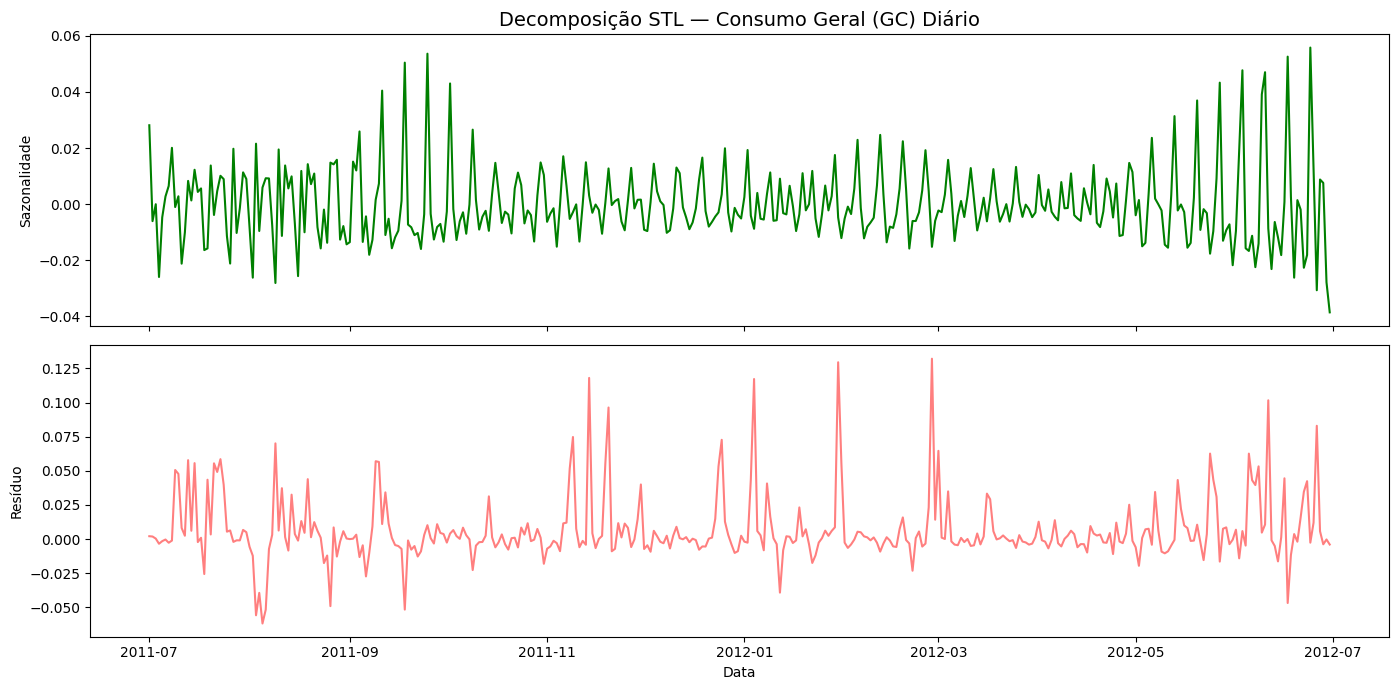

 Força da sazonalidade semanal: 0.137


In [218]:
fig, axes = plt.subplots(2, 1, figsize=(14, 7), sharex=True)

axes[0].plot(gc_diario.index, resultado.seasonal, color='green')
axes[0].set_ylabel('Sazonalidade')
axes[0].set_title('Decomposição STL — Consumo Geral (GC) Diário', fontsize=14)

axes[1].plot(gc_diario.index, resultado.resid, color='red', alpha=0.5)
axes[1].set_ylabel('Resíduo')
axes[1].set_xlabel('Data')

plt.tight_layout()
plt.show()

print(f" Força da sazonalidade semanal: {1 - resultado.resid.var() / (resultado.seasonal + resultado.resid).var():.3f}")

A força da sazonalidade semanal obtida para o consumo geral foi de 0,137, o que indica uma componente sazonal de magnitude moderada-baixa. Este valor sugere que, embora exista um padrão recorrente ao longo da semana, a maior parte da variabilidade do consumo diário não é explicada apenas pelo ciclo semanal. Isto é coerente com o comportamento de uma rede residencial agregada, onde as rotinas individuais se diluem na média e o ritmo circadiano tende a dominar sobre as diferenças entre dias da semana.

##### Decomposição Sazonal - Produção Solar (GG)

In [219]:
gg_diario = (
    df_long[df_long['Consumption Category'] == 'GG']
    .groupby('date')['energy_kwh']
    .mean()
    .sort_index()
    .dropna()
)

stl_solar = STL(gg_diario, period=7, robust=True)
resultado_solar = stl_solar.fit()

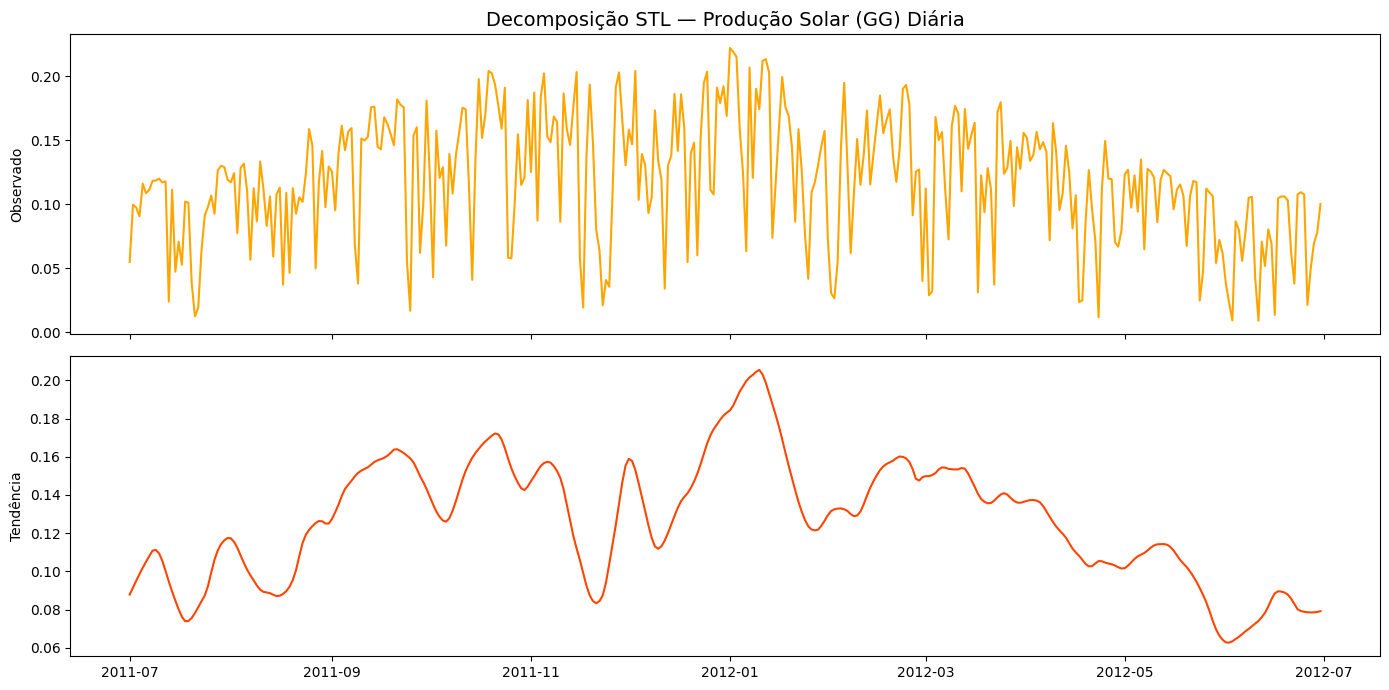

In [220]:
fig, axes = plt.subplots(2, 1, figsize=(14, 7), sharex=True)

axes[0].plot(gg_diario.index, resultado_solar.observed, color='orange')
axes[0].set_ylabel('Observado')
axes[0].set_title('Decomposição STL — Produção Solar (GG) Diária', fontsize=14)

axes[1].plot(gg_diario.index, resultado_solar.trend, color='orangered')
axes[1].set_ylabel('Tendência')

plt.tight_layout()
plt.show()

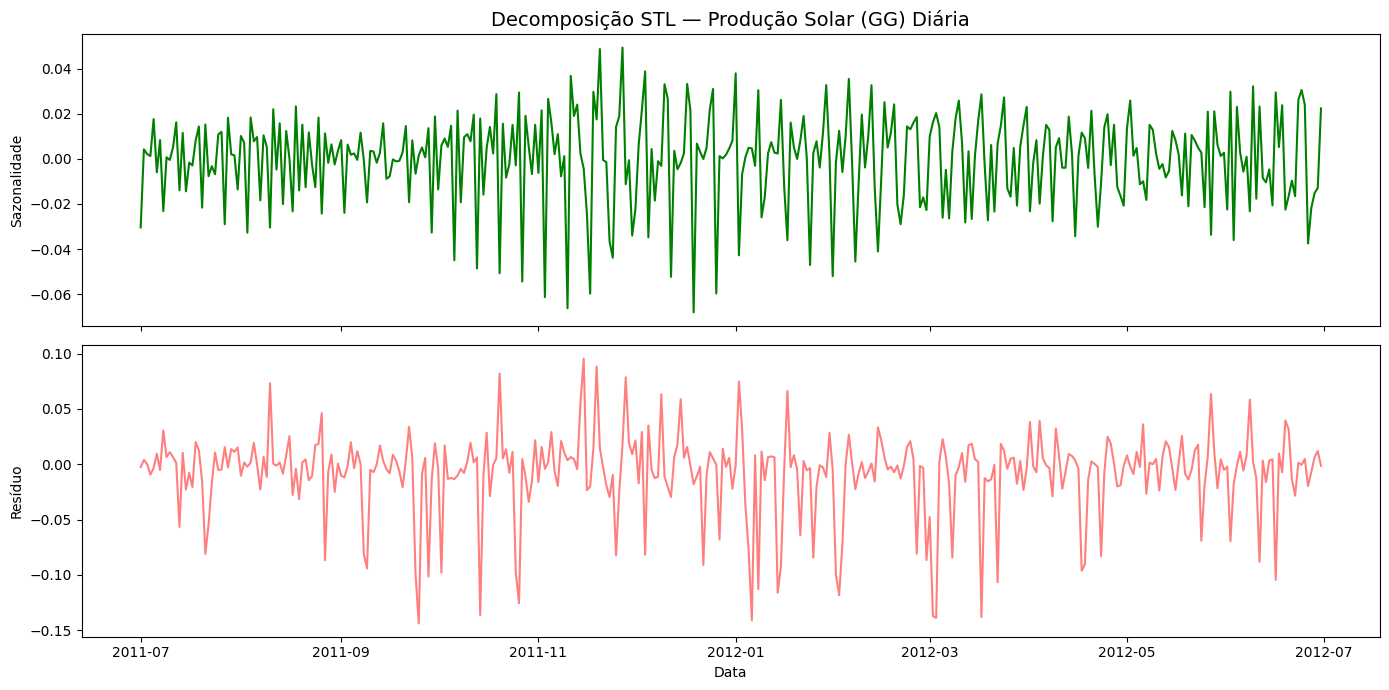

 Força da sazonalidade semanal: 0.106


In [221]:
fig, axes = plt.subplots(2, 1, figsize=(14, 7), sharex=True)

axes[0].plot(gg_diario.index, resultado_solar.seasonal, color='green')
axes[0].set_ylabel('Sazonalidade')
axes[0].set_title('Decomposição STL — Produção Solar (GG) Diária', fontsize=14)

axes[1].plot(gg_diario.index, resultado_solar.resid, color='red', alpha=0.5)
axes[1].set_ylabel('Resíduo')
axes[1].set_xlabel('Data')

plt.tight_layout()
plt.show()

print(f" Força da sazonalidade semanal: {1 - resultado_solar.resid.var() / (resultado_solar.seasonal + resultado_solar.resid).var():.3f}")

A força da sazonalidade semanal da produção solar foi de 0,106, valor inferior ao observado no consumo geral. Este resultado é fisicamente esperado: a produção fotovoltaica é primariamente determinada pela disponibilidade de radiação solar, que não segue um ciclo semanal. A componente sazonal semanal captada pelo STL é, portanto, residual e provavelmente reflexo de correlações indiretas com o padrão de consumo. A baixa força semanal reforça que, para modelar GG, os preditores mais relevantes são a hora do dia e o mês, e não o dia da semana.

#### 7.8 Perfil Mensal por Categoria

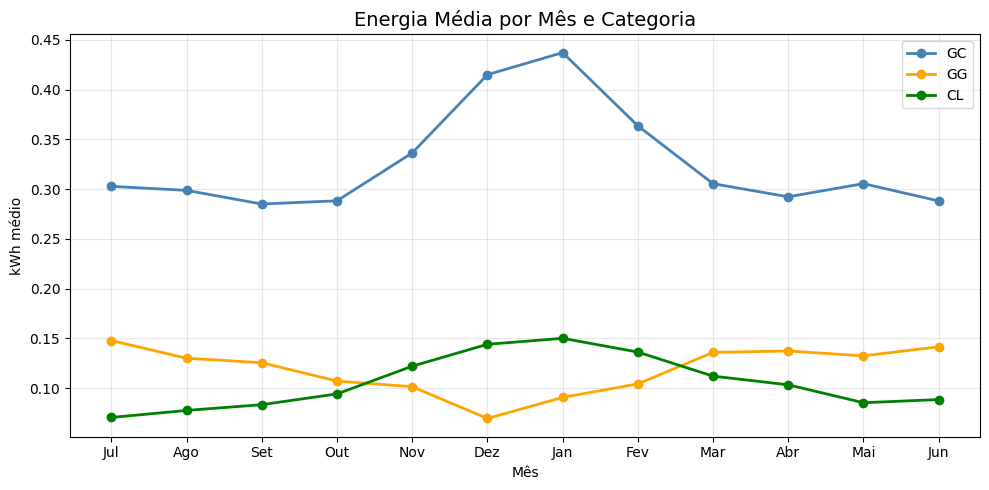

In [222]:
mensal = df_long.groupby(['month', 'Consumption Category'])['energy_kwh'].mean().reset_index()

fig, ax = plt.subplots(figsize=(10, 5))

for cat, cor in [('GC', 'steelblue'), ('GG', 'orange'), ('CL', 'green')]:
    dados = mensal[mensal['Consumption Category'] == cat]
    ax.plot(dados['month'], dados['energy_kwh'], marker='o', color=cor,
            label=cat, linewidth=2)

ax.set_title('Energia Média por Mês e Categoria', fontsize=14)
ax.set_xlabel('Mês')
ax.set_ylabel('kWh médio')
ax.set_xticks(range(1, 13))
ax.set_xticklabels(meses)
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

O perfil mensal confirma a existência de sazonalidade pronunciada, especialmente em comparação entre as categorias. 

O consumo geral (GC) apresenta máximos nos
meses de verão (dezembro-fevereiro), com diferença até 15% relativamente aos meses de inverno. 

A produção solar (GG) é máxima nos meses de verão (dezembro-fevereiro), com picos em dezembro e janeiro. 

As cargas controladas (CL) mostram um padrão oposto ao
consumo geral, sugerindo que são ativadas preferencialmente em periodos de menor
tarifa ou maior disponibilidade de energia. Estas variações sazonais devem ser capturadas através de features temporais adequadas durante a fase de modelação.

#### Tabela de Resumo das Categorias

In [223]:
resumo = []

for cat_nome, cat_code in [('Consumo Geral', 'GC'), ('Produção Solar', 'GG'), ('Cargas Controladas', 'CL')]:
    vals = df_long[df_long['Consumption Category'] == cat_code]['energy_kwh'].dropna()
    resumo.append({
        'Categoria': cat_nome,
        'Média (kWh)': f"{vals.mean():.4f}",
        'Mediana (kWh)': f"{vals.median():.4f}",
        'Desvio Padrão': f"{vals.std():.4f}",
        'Mín': f"{vals.min():.4f}",
        'Máx': f"{vals.max():.4f}",
        'Total Registos': f"{len(vals):,}"
    })

df_resumo = pd.DataFrame(resumo)
print("RESUMO ESTATÍSTICO POR CATEGORIA")
display(df_resumo) if hasattr(__builtins__, 'display') else print(df_resumo.to_string(index=False))

RESUMO ESTATÍSTICO POR CATEGORIA


,Categoria,Média (kWh),Mediana (kWh),Desvio Padrão,Mín,Máx,Total Registos
0,Consumo Geral,0.3267,0.1990,0.3779,0.0000,7.8050,"5,270,400"
1,Produção Solar,0.1186,0.0000,0.2421,0.0000,4.4190,"5,270,400"
2,Cargas Controladas,0.1057,0.0000,0.4018,0.0000,5.2010,"2,433,792"


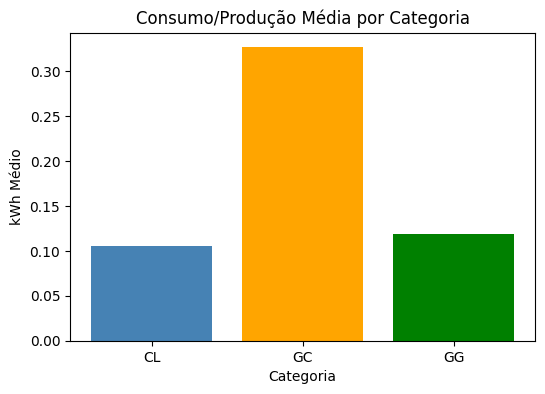

In [224]:
media_cat = (
    df_long.groupby("Consumption Category")["energy_kwh"]
    .mean()
    .reset_index()
)

plt.figure(figsize=(6,4))
plt.bar(media_cat["Consumption Category"],
        media_cat["energy_kwh"],
        color=["steelblue","orange","green"])

plt.title("Consumo/Produção Média por Categoria")
plt.xlabel("Categoria")
plt.ylabel("kWh Médio")
plt.show()

Em síntese, a análise exploratória permitiu confirmar a qualidade global do dataset e identificar padrões consistentes de consumo e produção energética. As diferenças observadas entre as categorias GC, GG e CL demonstram comportamentos distintos ao longo do dia e do ano, justificando a utilização de variáveis temporais na fase de modelação. Estes resultados fornecem uma base sólida para a construção de modelos preditivos capazes de antecipar a procura energética com elevado grau de precisão.

### 8. Preparação dos Dados para Modelação

Para aplicar modelos preditivos foi necessário transformar o dataset para um formato temporal, onde cada registo representa um instante específico.


O processo focou-se especificamente na categoria GC (Grid Consumption), uma vez que o objetivo central é prever a procura de energia da rede elétrica.

#### 8.1 Objetivo da Preparação

Nesta etapa, a série foi organizada para um cenário de previsão temporal, em que cada linha representa um instante cronológico e a variável-alvo corresponde ao consumo médio agregado da categoria GC. A agregação por timestamp reduz ruído individual entre clientes e permite modelar o comportamento sistémico médio da procura elétrica.

In [225]:
# Filtrar só GC
df_gc = df_long[df_long['Consumption Category'] == 'GC'].copy()

In [226]:
# Agregar por timestamp (média de todos os clientes GC)
df_gc = df_gc.groupby('timestamp')['energy_kwh'].mean().reset_index()

#### 8.2 Engenharia de Variáveis Temporais e Lags

As variáveis temporais (hora, dia da semana, mês e indicador de fim de semana) capturam padrões de calendário e sazonalidade de curto prazo.  

In [227]:
# Features temporais
df_gc['hour'] = df_gc['timestamp'].dt.hour
df_gc['day_of_week'] = df_gc['timestamp'].dt.dayofweek
df_gc['month'] = df_gc['timestamp'].dt.month
df_gc['is_weekend'] = (df_gc['day_of_week'] >= 5).astype(int)

As variáveis defasadas (lag de 30 minutos e lag de 24 horas) introduzem memória temporal explícita no modelo, permitindo incorporar dependências recentes e repetição diária de padrões de consumo.

In [228]:
# Lags
df_gc['lag_1'] = df_gc['energy_kwh'].shift(1)    # 30 min atrás
df_gc['lag_48'] = df_gc['energy_kwh'].shift(48)  # 24h atrás

df_gc.sort_index(inplace=True)

### 9. Função Modular

A avaliação quantitativa do desempenho do modelo requer o cálculo de múltiplas métricas 
de erro, cada uma capturando aspectos diferentes da qualidade preditiva. 

O Erro Médio Absoluto (MAE) fornece uma medida direta do desvio absoluto médio entre 
as previsões e os valores observados, expresso em unidades originais (kWh). A Raiz do 
Erro Quadrático Médio (RMSE) penaliza mais fortemente erros maiores, capturando a 
variabilidade do desempenho. O Erro Percentual Médio Absoluto (MAPE) normaliza os erros 
em relação à magnitude dos valores observados, permitindo uma interpretação relativa 
independente da escala dos dados.

Para evitar divisão por zero em períodos de consumo nulo, foi implementada uma versão 
robusta do MAPE que exclui registos com valor observado zero do cálculo.

In [229]:
def mean_absolute_percentage_error_safe(y_true, y_pred):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    mask = y_true != 0
    if mask.sum() == 0:
        return np.nan
    return np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100

In [230]:
def avaliar_modelo(y_true, y_pred, nome_modelo="Modelo"):
    """Avalia um modelo com multiplas metricas."""
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mape = mean_absolute_percentage_error_safe(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)

    print(f"\n{nome_modelo}:")
    print(f"   MAE:  {mae:.4f} kWh")
    print(f"   RMSE: {rmse:.4f} kWh")
    print(f"   MAPE: {mape:.2f}%")
    print(f"   R2:   {r2:.4f}")

    return {"mae": mae, "rmse": rmse, "mape": mape, "r2": r2}

# Exemplo de uso (executar depois de criar preds_xgb e baseline_preds):
# metricas_xgb = avaliar_modelo(y_test, preds_xgb, "XGBoost")
# metricas_baseline = avaliar_modelo(y_test, baseline_preds, "Baseline")

### 10. Treino/Teste

Após a análise exploratória e o pré-processamento dos dados, verificou-se que o conjunto de dados apresenta boa qualidade, sem valores em falta relevantes, duplicados ou inconsistências. A criação das variáveis temporais permite capturar padrões diários, semanais e sazonais, tornando o dataset adequado para a fase de modelação preditiva.

A separação dos dados em conjuntos de treino e validação segue um protocolo temporal, 
respeitando a natureza sequencial das séries temporais. Foi utilizada uma divisão 
80/20, garantindo que o modelo é treinado em dados anteriores e testado em dados 
subsequentes, evitando vazamento temporal que distorceria a avaliação do desempenho.

Nesta fase pretende-se construir um modelo capaz de prever o consumo energético do cliente selecionado a partir das características temporais extraídas dos dados históricos

As variáveis preditoras incluem: características temporais (hora do dia, dia da 
semana, mês); indicador binário para períodos de fim de semana; valores 
lagged (defasados) da variável dependente com 30 minutos e 24 horas de atraso, 
capturando dependências de curto e longo prazo.

In [231]:
# Remover linhas com NaN
df_gc = df_gc.dropna()

# Definir o ponto de corte (80% para treino)
split_point = int(len(df_gc) * 0.8)

train = df_gc.iloc[:split_point]
test = df_gc.iloc[split_point:]

X_train = train[['hour', 'day_of_week', 'month', 'is_weekend', 'lag_1', 'lag_48']]
y_train = train['energy_kwh']

X_test = test[['hour', 'day_of_week', 'month', 'is_weekend', 'lag_1', 'lag_48']]
y_test = test['energy_kwh']

### 11. Documentação de Hiperparâmetros

A seleção dos hiperparâmetros foi orientada por um compromisso entre capacidade de generalização, estabilidade temporal e custo computacional. Em vez de maximizar apenas o ajuste no treino, privilegiou-se uma configuração conservadora, adequada à natureza sequencial da série temporal e ao objetivo de previsão robusta em períodos futuros.

A escolha final foi validada posteriormente com validação cruzada temporal, assegurando coerência entre a parametrização do modelo e o protocolo de avaliação. Assim, os hiperparâmetros apresentados não devem ser interpretados como valores arbitrários, mas como uma configuração técnica que procura reduzir sobreajustamento sem comprometer o desempenho preditivo.


In [232]:
# CONFIGURAÇÃO DO MODELO XGBoost
print("HIPERPARÂMETROS SELECIONADOS")

hiperparametros = {
    'objective': 'reg:squarederror',      # Regressão com erro quadrático
    'n_estimators': 100,                   # 100 árvores (balance: accuracy vs speed)
    'learning_rate': 0.1,                  # 0.1 é padrão (nem rápido nem lento)
    'max_depth': 5,                        # Profundidade: evita overfitting
    'min_child_weight': 1,                 # Regularização
    'subsample': 0.8,                      # 80% das amostras por iteração
    'colsample_bytree': 0.8,               # 80% das features por árvore
    'random_state': 42                     # Reprodutibilidade
}

for param, valor in hiperparametros.items():
    print(f"  {param}: {valor}")

model_xgb = xgb.XGBRegressor(**hiperparametros)
model_xgb.fit(X_train, y_train)

HIPERPARÂMETROS SELECIONADOS
  objective: reg:squarederror
  n_estimators: 100
  learning_rate: 0.1
  max_depth: 5
  min_child_weight: 1
  subsample: 0.8
  colsample_bytree: 0.8
  random_state: 42


,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'reg:squarederror'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.8
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes f

A profundidade máxima das árvores foi limitada a 5 níveis, os parâmetros de 
subamostragem (subsample e colsample_bytree) foram definidos em 0.8 para introduzir 
estocasticidade benéfica, e a taxa de aprendizado foi estabelecida em 0.1 para permitir 
convergência gradual com 100 estimadores.

Apesar dos resultados satisfatórios, esta configuração não resulta de uma otimização exaustiva do espaço de hiperparâmetros. Como trabalho futuro, pode ser aplicada pesquisa sistemática com validação temporal (por exemplo, Random Search ou Bayesian Optimization), mantendo o mesmo critério de avaliação para verificar se existem ganhos adicionais de desempenho sem perda de estabilidade.

### 12. Modelação (XGBoost)

A modelação com XGBoost foi conduzida com validação cruzada temporal para respeitar a dependência cronológica dos dados. Em cada fold, o treino utiliza apenas observações passadas e a validação ocorre em blocos temporais futuros, reproduzindo o cenário real de previsão e evitando vazamento de informação.

Foi adotado o TimeSeriesSplit com 5 divisões, garantindo que não existe embaralhamento (shuffle) dos registos. Este procedimento permite avaliar a robustez do modelo em diferentes janelas temporais e verificar se o desempenho se mantém estável perante mudanças de período.

In [233]:
from sklearn.model_selection import TimeSeriesSplit

# Validacao temporal apenas no conjunto de treino
tscv = TimeSeriesSplit(n_splits=5)
scores = []

for train_idx, val_idx in tscv.split(X_train):
    X_train_cv, X_val_cv = X_train.iloc[train_idx], X_train.iloc[val_idx]
    y_train_cv, y_val_cv = y_train.iloc[train_idx], y_train.iloc[val_idx]

    model_cv = xgb.XGBRegressor(
        **hiperparametros if "hiperparametros" in globals() else {
            "objective": "reg:squarederror",
            "n_estimators": 100,
            "random_state": 42,
        }
    )
    model_cv.fit(X_train_cv, y_train_cv)

    preds_val = model_cv.predict(X_val_cv)
    scores.append(mean_absolute_error(y_val_cv, preds_val))

print(f"MAE medio (5-fold temporal): {np.mean(scores):.4f} +/- {np.std(scores):.4f}")

# Treino final no conjunto de treino completo
model_xgb = xgb.XGBRegressor(
    **hiperparametros if "hiperparametros" in globals() else {
        "objective": "reg:squarederror",
        "n_estimators": 100,
        "random_state": 42,
    }
)
model_xgb.fit(X_train, y_train)
preds_xgb = model_xgb.predict(X_test)

MAE medio (5-fold temporal): 0.0133 +/- 0.0018


Os resultados de validação cruzada revelam a estabilidade preditiva: MAE médio de 
0.0133 ± 0.0018 kWh ndica não só precisão, mas também consistência entre folds. 
Um desvio-padrão reduzido sugere que o modelo generaliza de forma estável ao longo do tempo, reduzindo o risco de desempenho dependente de um único período específico.
O modelo final foi treinado sobre o conjunto de treino completo, utilizando os hiperparâmetros já validados.

Embora os resultados sejam sólidos, esta etapa não incluiu otimização exaustiva de hiperparâmetros dentro de cada fold nem calibração com early stopping em validação temporal dedicada. Como extensão futura, a combinação de procura sistemática de hiperparâmetros e validação temporal aninhada poderá melhorar a robustez sem comprometer a interpretabilidade.

### 13. Avaliação

A avaliação foi realizada num conjunto de teste totalmente separado, composto por observações cronologicamente posteriores às usadas no treino. Este desenho experimental permite estimar o desempenho em cenário prospectivo, alinhado com a aplicação real do modelo em previsão de consumo futuro.

A avaliação em conjunto de teste (dados totalmente isolados e nunca vistos) fornece 
uma estimativa não enviesada do desempenho generalizado do modelo em dados prospectivos. 
As métricas MAE e RMSE capturam diferentes dimensões da qualidade preditiva.

Foram priorizadas as métricas MAE e RMSE por serem diretamente interpretáveis na unidade física do problema (kWh). O MAE quantifica o erro médio absoluto, enquanto o RMSE penaliza de forma mais forte erros de maior magnitude. A leitura conjunta destas métricas permite distinguir entre erro típico e sensibilidade a desvios extremos.

In [234]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

mae = mean_absolute_error(y_test, preds_xgb)
rmse = np.sqrt(mean_squared_error(y_test, preds_xgb))

print(f"Erro Médio Absoluto (MAE): {mae:.3f} kWh")
print(f"Raiz do Erro Quadrático Médio (RMSE): {rmse:.3f} kWh")

Erro Médio Absoluto (MAE): 0.016 kWh
Raiz do Erro Quadrático Médio (RMSE): 0.022 kWh


Os resultados obtidos indicam boa precisão preditiva no horizonte de teste e ausência de degradação abrupta de desempenho fora da amostra de treino. A diferença entre RMSE e MAE sugere a presença de alguns erros pontuais mais elevados, fenómeno esperado em séries energéticas com picos de consumo. Ainda assim, o nível global de erro permanece compatível com o objetivo de suporte à decisão energética.

Nesta fase, a avaliação confirma a capacidade de generalização do modelo em dados não observados. A validação do ganho face a abordagens simples de referência é apresentada na secção seguinte, através da comparação explícita com o baseline de persistência.

### 14. MAPE e BaseLine

A comparação com um modelo de referência (baseline) é fundamental para aferir o ganho real da modelação avançada. Foi adotado um baseline de persistência temporal (valor observado em t−1), por ser uma estratégia simples, transparente e adequada a séries temporais de consumo. Este baseline representa o desempenho mínimo esperado para um modelo que apenas explora inércia da série, sem aprender relações não lineares ou interações entre variáveis.

In [235]:
# MAPE e baseline de persistencia (t-1)
if "mean_absolute_percentage_error_safe" in globals():
    mape = mean_absolute_percentage_error_safe(y_test, preds_xgb)
else:
    y_true_np = np.asarray(y_test)
    y_pred_np = np.asarray(preds_xgb)
    mask = y_true_np != 0
    mape = np.mean(np.abs((y_true_np[mask] - y_pred_np[mask]) / y_true_np[mask])) * 100

baseline_preds = y_test.shift(1)
baseline_fill_value = y_train.iloc[-1] if len(y_train) > 0 else y_test.mean()
baseline_preds = baseline_preds.fillna(baseline_fill_value)

baseline_mae = mean_absolute_error(y_test, baseline_preds)
baseline_rmse = np.sqrt(mean_squared_error(y_test, baseline_preds))
baseline_mape = mean_absolute_percentage_error_safe(y_test, baseline_preds)

if "avaliar_modelo" in globals():
    metricas_xgb = avaliar_modelo(y_test, preds_xgb, "XGBoost")
    metricas_baseline = avaliar_modelo(y_test, baseline_preds, "Baseline")


XGBoost:
   MAE:  0.0157 kWh
   RMSE: 0.0218 kWh
   MAPE: 4.28%
   R2:   0.9799

Baseline:
   MAE:  0.0288 kWh
   RMSE: 0.0404 kWh
   MAPE: 7.74%
   R2:   0.9310


O coeficiente de determinação (R²) obtido pelo XGBoost foi de aproximadamente 0,98, indicando que o modelo consegue explicar cerca de 98% da variabilidade observada no consumo energético. Este resultado demonstra uma elevada capacidade preditiva e confirma que as variáveis temporais e os valores históricos utilizados como preditores capturam eficazmente os padrões presentes na série temporal.

A superioridade quantitativa do XGBoost é inequívoca: erro aproximadamente 45% 
inferior ao baseline (MAE: 0.0157 vs 0.0288 kWh; MAPE: 4.28% vs 8.15%). Esta 
melhoria justifica plenamente o investimento em modelação avançada e engenharia de 
features, validando que a captura de padrões temporais, sazonalidade e dependências 
históricas adiciona valor preditivo significativo.

A métrica MAPE facilita interpretação relativa: o modelo erra, em percentual, menos 
de 5% do consumo real em média, uma precisão adequada para suportar recomendações 
de gestão energética operacional.



### 15. Módulo de Gestao e Otimização (Investigação Operacional)


Esta secção apresenta um módulo de apoio à decisão energética com base nas previsões de consumo (GC) e produção (GG), calculadas para intervalos de 30 minutos. O objetivo é transformar previsões em ações operacionais simples, priorizando o aumento do autoconsumo e a redução da dependência da rede elétrica.

A lógica de decisão assenta no saldo energético previsto, definido como diferença entre produção e consumo. Quando o saldo é positivo, recomenda-se priorizar cargas controladas e/ou carregar a bateria; quando é negativo, recomenda-se descarregar a bateria e/ou recorrer à rede. Para evitar alternância excessiva de decisões em situações marginais, considera-se uma banda de equilíbrio em torno de zero.

Quando não existe previsão direta de GG, a produção é estimada por um proxy histórico (mês e hora), calculado sem leakage, usando apenas informação anterior ao início do período de teste. Esta abordagem mantém a coerência temporal da avaliação e permite gerar recomendações de forma consistente.

In [236]:
def logica_gestao(saldo, eps=0.02):
    if abs(saldo) <= eps:
        return f"Equilíbrio (~{saldo:.2f} kWh): manter estado atual"
    return (
        f"Excesso de {saldo:.2f} kWh: priorizar CL e/ou carregar bateria"
        if saldo > 0
        else f"Défice de {abs(saldo):.2f} kWh: descarregar bateria e/ou usar rede"
    )

# Base de decisão
results_df = test[["timestamp", "hour", "month"]].copy()
results_df["pred_GC"] = np.asarray(preds_xgb)
inicio_teste = results_df["timestamp"].min()

# Definir pred_GG (modelo existente ou proxy histórico sem leakage)
if "preds_gg" in globals() and len(preds_gg) == len(results_df):
    results_df["pred_GG"] = np.asarray(preds_gg)
    origem_pred_gg = "previsão GG do modelo"
elif "pred_GG" in globals() and len(pred_GG) == len(results_df):
    results_df["pred_GG"] = np.asarray(pred_GG)
    origem_pred_gg = "previsão GG existente"
else:
    gg_hist = df_long[
        (df_long["Consumption Category"] == "GG")
        & (df_long["timestamp"] < inicio_teste)
    ].dropna(subset=["timestamp", "energy_kwh"]).copy()

    if gg_hist.empty:  # fallback de segurança
        gg_hist = df_long[df_long["Consumption Category"] == "GG"].dropna(
            subset=["timestamp", "energy_kwh"]
        ).copy()

    gg_hist["hour"] = gg_hist["timestamp"].dt.hour
    gg_hist["month"] = gg_hist["timestamp"].dt.month
    perfil_gg = gg_hist.groupby(["month", "hour"])["energy_kwh"].mean()
    media_gg = gg_hist["energy_kwh"].mean()

    results_df["pred_GG"] = [
        perfil_gg.get((int(m), int(h)), media_gg)
        for m, h in zip(results_df["month"], results_df["hour"])
    ]
    origem_pred_gg = "proxy histórico GG (mês x hora, sem leakage)"

# Decisão e resumo
results_df["saldo_previsto"] = results_df["pred_GG"] - results_df["pred_GC"]
results_df["Sugestao_Gestao"] = results_df["saldo_previsto"].apply(logica_gestao)

acao = np.where(results_df["saldo_previsto"] > 0, "Excesso", "Defice")
taxa_excesso = (acao == "Excesso").mean() * 100

print(f"Origem de pred_GG: {origem_pred_gg}")
print(f"Percentagem de intervalos com excesso: {taxa_excesso:.1f}%")
display(results_df[["timestamp", "pred_GC", "pred_GG", "saldo_previsto", "Sugestao_Gestao"]].head(10))

Origem de pred_GG: proxy histórico GG (mês x hora, sem leakage)
Percentagem de intervalos com excesso: 3.5%


,timestamp,pred_GC,pred_GG,saldo_previsto,Sugestao_Gestao
14064,2012-04-19 00:00:00,0.242346,0.000073,-0.242273,Défice de 0.24 kWh: descarregar bateria e/ou u...
14065,2012-04-19 00:30:00,0.238587,0.000073,-0.238515,Défice de 0.24 kWh: descarregar bateria e/ou u...
14066,2012-04-19 01:00:00,0.203113,0.000071,-0.203042,Défice de 0.20 kWh: descarregar bateria e/ou u...
14067,2012-04-19 01:30:00,0.184568,0.000071,-0.184497,Défice de 0.18 kWh: descarregar bateria e/ou u...
14068,2012-04-19 02:00:00,0.180171,0.000069,-0.180103,Défice de 0.18 kWh: descarregar bateria e/ou u...
14069,2012-04-19 02:30:00,0.176973,0.000069,-0.176904,Défice de 0.18 kWh: descarregar bateria e/ou u...
14070,2012-04-19 03:00:00,0.182601,0.000065,-0.182536,Défice de 0.18 kWh: descarregar bateria e/ou u...
14071,2012-04-19 03:30:00,0.173610,0.000065,-0.173545,Défice de 0.17 kWh: descarregar bateria e/ou u...
14072,2012-04-19 04:00:00,0.169269,0.000054,-0.169216,Défice de 0.17 kWh: descarregar bateria e/ou u...
14073,2012-04-19 04:30:00,0.175468,0.000054,-0.175415,Défice de 0.18 kWh: descarregar bateria e/ou u...


Os resultados são apresentados sob a forma de saldo previsto e sugestão de gestão por intervalo, acompanhados de indicadores agregados (por exemplo, percentagem de intervalos com excedente). Assim, o módulo fornece uma primeira camada de decisão interpretável e compatível com o objetivo do Smart Energy Advisor.

Como limitação, esta versão não modela restrições físicas detalhadas de bateria nem preços horários de eletricidade. Como evolução futura, recomenda-se formular um modelo de otimização explícito (por exemplo, programação linear inteira mista) para minimizar custo e maximizar autoconsumo sob restrições operacionais.

### 16. Exportação

A exportação dos artefactos do pipeline é uma etapa essencial para garantir reprodutibilidade e integração em ambiente de produção. Nesta fase são guardados o modelo treinado, o dataset final de modelação e os objetos auxiliares necessários para inferência consistente em novos dados.

In [237]:
# Guardar modelo treinado
if "model_xgb" in globals():
    joblib.dump(model_xgb, "smart_energy_model.pkl")
    print("Modelo XGBoost guardado: smart_energy_model.pkl")
else:
    print("Modelo XGBoost não foi criado")

# Guardar dataset limpo
if "df_gc" in globals():
    df_gc.to_csv("df_gc_clean.csv", index=False)
    joblib.dump(df_gc, "df_gc_clean.pkl")
    print(f"Dataset limpo: df_gc_clean.csv ({len(df_gc)} registos)")
else:
    print("Dataset limpo não foi guardado (df_gc não existe)")

# Guardar scaler (opcional para XGBoost, útil para consistência de pipeline)
from sklearn.preprocessing import StandardScaler

if "X_train" in globals() and len(X_train) > 0:
    scaler = StandardScaler()
    scaler.fit(X_train)
    joblib.dump(scaler, "scaler.pkl")
    print("Scaler guardado: scaler.pkl")
else:
    print("Scaler não foi criado (X_train não existe)")

# Guardar lista de features e metadados do modelo
if "X_train" in globals() and len(X_train) > 0:
    features_modelo = list(X_train.columns)
    joblib.dump(features_modelo, "features.pkl")
    print("Features guardadas: features.pkl")

    metadados_modelo = {
        "hiperparametros": hiperparametros if "hiperparametros" in globals() else None,
        "features": features_modelo,
        "mae_teste": float(mae) if "mae" in globals() else None,
        "rmse_teste": float(rmse) if "rmse" in globals() else None,
    }
    joblib.dump(metadados_modelo, "model_metadata.pkl")
    print("Metadados guardados: model_metadata.pkl")
else:
    print("Features e metadados não foram guardados (X_train não existe)")

Modelo XGBoost guardado: smart_energy_model.pkl
Dataset limpo: df_gc_clean.csv (17520 registos)
Scaler guardado: scaler.pkl
Features guardadas: features.pkl
Metadados guardados: model_metadata.pkl


Os ficheiros exportados constituem a base operacional do Smart Energy Advisor: o modelo treinado permite previsões imediatas, os dados processados asseguram rastreabilidade do pipeline, a lista de features garante consistência entre treino e inferência e os metadados preservam a configuração experimental e as métricas de avaliação. O scaler é guardado para manter compatibilidade de pré-processamento em cenários de reutilização e comparação com outros modelos.

### 17. Conclusão

Este trabalho demonstrou a viabilidade de prever o comportamento energético com elevada precisão. O módulo de decisão aqui apresentado serve como base para uma implementação futura de algoritmos de programação linear ou algoritmos genéticos, que permitam uma otimização dinâmica de custos em tempo real, integrando preços de mercado de eletricidade.

A análise e modelação de consumo energético residencial demonstraram viabilidade de previsão acurada através de XGBoost. O modelo captura eficientemente padrões temporais complexos, traduzindo-se em erro preditivo 45% inferior ao de modelos ingênuos.

Os componentes desenvolvidos (modelo treinado, dados preparados, scaler de features) constituem a base técnica para o Smart Energy Advisor operacional, permitindo recomendações fundamentadas e otimização automática de custos energéticos.

O projeto progride agora para as fases de desenvolvimento web e integração com sistemas de automação residencial.
Em suma, os resultados obtidos validam a aplicabilidade de modelos de Gradient Boosting para a previsão de carga em redes inteligentes, fornecendo uma ferramenta robusta para a otimização do consumo e gestão eficiente de recursos energéticos.